<a id="etapa-4"></a>

# **Entrega Final**

**Datasets:** `ventas.csv`, `clientes.csv`, `marketing.csv` (en Drive).

### Mapeo a la rúbrica
###Etapa 1: Recopilación y Preparación de Datos
1. 1-Crear un documento en Google Colaboratory y cargar los sets de datos como DataFrames.
4. 4-Introducción a Pandas: realizar un análisis exploratorio inicial de los DataFrames.
5. 5-Calidad de Datos: Identificar valores nulos y duplicados en los conjuntos de datos. Documentar el estado inicial de los datos.
###Etapa 2: Preprocesamiento y Limpieza de Datos
1. Limpieza de Datos: Limpiar el conjunto de datos eliminando duplicados y caracteres no deseados. Documentar el proceso y los resultados.
2. Transformación de Datos: Aplicar filtros y transformaciones para crear una tabla de ventas que muestre solo los productos con alto rendimiento.
3. Agregación: Resumir las ventas por categoría de producto y analizar los ingresos generados.
4. Integración de Datos: Combinar los sets de datos de ventas y marketing para obtener una visión más amplia de las tendencias.
###Etapa 3: Análisis de Datos
1. Estadística Descriptiva: Calcular medidas de tendencia central y dispersión sobre las ventas. Presentar los resultados en un informe.
2. Análisis Exploratorio de Datos (EDA): Realizar un análisis exploratorio utilizando visualizaciones para identificar patrones y tendencias en las ventas.
3. Correlación: Evaluar la relación entre diferentes variables (por ejemplo, precio y cantidad vendida) y mostrar los resultados en un gráfico.
###Etapa 4: Visualización de Datos
1. Visualización con Matplotlib: Crear gráficos básicos (líneas, barras, dispersión)
2. Visualización Avanzada con Seaborn: Desarrollar visualizaciones estadísticas avanzadas, utilizando paletas y estilos para mejorar la presentación.
4. Presentación Final: Preparar una presentación que resuma los hallazgos, insights y visualizaciones generadas a lo largo del proyecto.



## RESUMEN DE DATASETS
FLUJO DE TRANSFORMACIÓN:
ventas → ventas_clean → ventas_perf → resumen_prod → ventas_top
                              ↓
                        ventas_cat → resumen_cat

###ventas : dataset original sin procesar
###ventas_clean: dataset original despues de limpiar datos
###ventas_perf: dataset de ventas_clean con el campo ingreso que es precio*cantidad de cada factura
###resumen_prod: dataset de ventas_perf agrupado por producto y sumado el ingreso de cada venta = ingreso_total
###ventas_top: el detaset de resumen_prod, que tiene productos agrupados, pero solo me quedo con los productos mas vendidos (top del 20%)
###ventas_cat: el dataset de ventas_perf que se copio y se llama ventas_cat
###resumen_cat: del dataset de ventas_perf agrupo por categoria de producto y sumo ingreso_total

## Etapa1: 1. Crear un documento en Google Colaboratory y cargar los sets de datos como DataFrames.

In [607]:
import pandas as pd
import numpy as np

In [608]:
# Montar la unidad
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [609]:
# Verificar que los archivos csv se encuentren en la carpeta datasets
import os
os.listdir("/content/drive/MyDrive/datasets")


['ventas.csv',
 'ventas.xlsx',
 'clientes.csv',
 'marketing.csv',
 'marketing_clean.csv',
 'clientes_clean.csv',
 'ventas_clean.csv']

In [610]:
# Definimos las rutas de los datasets.
# En Google Colab, si subís archivos, podés usar la carpeta /content o montar Drive.
# Rutas relativas para que sea fácil reemplazarlas si cambia la ubicación.
ruta_ventas = "/content/drive/MyDrive/datasets/ventas.csv"
ruta_clientes = "/content/drive/MyDrive/datasets/clientes.csv"
ruta_marketing = "/content/drive/MyDrive/datasets/marketing.csv"

# Cargamos los CSV como DataFrames.
ventas = pd.read_csv(ruta_ventas)
clientes = pd.read_csv(ruta_clientes)
marketing = pd.read_csv(ruta_marketing)

# Validamos formas para comprobar que se cargaron correctamente.
print("ventas.shape ->", ventas.shape)
print("clientes.shape ->", clientes.shape)
print("marketing.shape ->", marketing.shape)

# Mostramos las primeras filas de cada dataset para corroborar estructura de columnas.
display(ventas.head(5))
display(clientes.head(5))
display(marketing.head(5))

ventas.shape -> (3035, 6)
clientes.shape -> (567, 5)
marketing.shape -> (90, 6)


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024


##Etapa 1: 4. Introducción a Pandas: realizar un análisis exploratorio inicial de los DataFrames.

In [611]:

def eda(df, nombre):
    print(f"=== {nombre} ===")
    print("shape:", df.shape)
    print("columnas:", list(df.columns))
    print("dtypes:")
    print(df.dtypes)
    print("\nNulos por columna:")
    print(df.isna().sum())
    print("\nPrimeras filas:")
    display(df.head(5))
    print("\nDescribe (numérico):")
    display(df.describe(include='number'))
    print("Satisfactorio")

In [612]:
eda(ventas, "VENTAS (inicial)")

=== VENTAS (inicial) ===
shape: (3035, 6)
columnas: ['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta', 'categoria']
dtypes:
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object

Nulos por columna:
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0
dtype: int64

Primeras filas:


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos



Describe (numérico):


,id_venta,cantidad
count,3035.000000,3033.000000
mean,1499.851400,6.496538
std,866.465379,3.457250
min,1.000000,1.000000
25%,748.500000,3.000000
50%,1502.000000,7.000000
75%,2249.500000,9.000000
max,3000.000000,12.000000


Satisfactorio


In [613]:
eda(clientes, "CLIENTES (inicial)")

=== CLIENTES (inicial) ===
shape: (567, 5)
columnas: ['id_cliente', 'nombre', 'edad', 'ciudad', 'ingresos']
dtypes:
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object

Nulos por columna:
id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
dtype: int64

Primeras filas:


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65



Describe (numérico):


,id_cliente,edad,ingresos
count,567.000000,567.000000,567.000000
mean,284.000000,37.940035,34668.739012
std,163.823075,10.202885,12974.531446
min,1.000000,20.000000,170.290000
25%,142.500000,30.000000,26015.240000
50%,284.000000,37.000000,35066.830000
75%,425.500000,43.000000,42457.100000
max,567.000000,81.000000,88053.010000


Satisfactorio


In [614]:
eda(marketing, "MARKETING (inicial)")

=== MARKETING (inicial) ===
shape: (90, 6)
columnas: ['id_campanha', 'producto', 'canal', 'costo', 'fecha_inicio', 'fecha_fin']
dtypes:
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object

Nulos por columna:
id_campanha     0
producto        0
canal           0
costo           0
fecha_inicio    0
fecha_fin       0
dtype: int64

Primeras filas:


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024



Describe (numérico):


,id_campanha,costo
count,90.000000,90.000000
mean,45.500000,4.928667
std,26.124701,0.947750
min,1.000000,2.950000
25%,23.250000,4.372500
50%,45.500000,4.900000
75%,67.750000,5.562500
max,90.000000,7.390000


Satisfactorio


## ETAPA 1: 5. **Calidad de Datos**: Identificar valores nulos y duplicados en los conjuntos de datos. Documentar el estado inicial de los datos.

In [615]:
# CONTROL DE CALIDAD DE DATOS

##(MEJORAR CÓDIGO)

import pandas as pd
# Asumimos que los DataFrames 'ventas', 'clientes' y 'marketing' ya están cargados.

def diagnosticar_dataframe(df: pd.DataFrame, nombre_df: str, columna_clave: str):
    """
    Realiza un análisis de control de calidad para un DataFrame específico.

    Args:
        df (pd.DataFrame): El DataFrame a analizar.
        nombre_df (str): Nombre del DataFrame para la salida impresa.
        columna_clave (str): Nombre de la columna clave (ID) para verificar duplicados.
    """
    print(f"\n\n{'=' * 50}")
    print(f"### DIAGNÓSTICO DE {nombre_df.upper()}")
    print(f"{'=' * 50}")

    # 1. Análisis de Valores Nulos
    print("\n1. Cantidad de valores nulos por columna:")
    nulos = df.isna().sum().to_frame("Nulos")
    # Calcula el porcentaje de nulos
    nulos['Porcentaje (%)'] = (nulos['Nulos'] / len(df) * 100).round(2)
    display(nulos)

    # 2. Análisis de Filas Duplicadas (Completas)
    dup_rows = df.duplicated(keep=False).sum()
    print(f"\n2. Filas duplicadas (exactas) encontradas: {dup_rows}")
    if dup_rows > 0:
        print("  Atención: Estas filas son réplicas exactas.")

    # 3. Análisis de Duplicados por Columna Clave
    dup_key_total = df[columna_clave].duplicated(keep=False).sum()
    print(f"\n3. Duplicados por clave '{columna_clave}': {dup_key_total} filas involucradas")

    if dup_key_total > 0:
        # 4. Top 10 Claves Duplicadas
        duplicados_ordenados = (
            df[df[columna_clave].duplicated(keep=False)][columna_clave]
            .value_counts()
            .sort_values(ascending=False)
        )
        print("\n   Top 10 claves duplicadas más frecuentes:")
        display(duplicados_ordenados.head(10))
    else:
        print(f"  La clave '{columna_clave}' está libre de duplicados.")


# ======================================================
# EJECUCIÓN DEL CONTROL DE CALIDAD
# ======================================================

# Análisis de VENTAS
diagnosticar_dataframe(ventas, "ventas", "id_venta")

# Análisis de CLIENTES
diagnosticar_dataframe(clientes, "clientes", "id_cliente")

# Análisis de MARKETING
diagnosticar_dataframe(marketing, "marketing", "id_campanha")



### DIAGNÓSTICO DE VENTAS

1. Cantidad de valores nulos por columna:


,Nulos,Porcentaje (%)
id_venta,0,0.00
producto,0,0.00
precio,2,0.07
cantidad,2,0.07
fecha_venta,0,0.00
categoria,0,0.00



2. Filas duplicadas (exactas) encontradas: 70
  Atención: Estas filas son réplicas exactas.

3. Duplicados por clave 'id_venta': 70 filas involucradas

   Top 10 claves duplicadas más frecuentes:


,count
id_venta,
56,2
421,2
424,2
1868,2
2545,2
2778,2
145,2
300,2
439,2




### DIAGNÓSTICO DE CLIENTES

1. Cantidad de valores nulos por columna:


,Nulos,Porcentaje (%)
id_cliente,0,0.0
nombre,0,0.0
edad,0,0.0
ciudad,0,0.0
ingresos,0,0.0



2. Filas duplicadas (exactas) encontradas: 0

3. Duplicados por clave 'id_cliente': 0 filas involucradas
  La clave 'id_cliente' está libre de duplicados.


### DIAGNÓSTICO DE MARKETING

1. Cantidad de valores nulos por columna:


,Nulos,Porcentaje (%)
id_campanha,0,0.0
producto,0,0.0
canal,0,0.0
costo,0,0.0
fecha_inicio,0,0.0
fecha_fin,0,0.0



2. Filas duplicadas (exactas) encontradas: 0

3. Duplicados por clave 'id_campanha': 0 filas involucradas
  La clave 'id_campanha' está libre de duplicados.



##ETAPA 2: 1. Limpieza de Datos: Limpiar el conjunto de datos eliminando duplicados y caracteres no deseados. Documentar el proceso y los resultados.


In [616]:

# ============================================
# LIMPIEZA Y NORMALIZACIÓN DE LOS DATASETS
# ============================================
# Se limpian y normalizan los DataFrames:
#   ventas, clientes, marketing
# ============================================

# -------------------------------------------------
# Crear copias independientes para no modificar los originales
# -------------------------------------------------
ventas_clean = ventas.copy()
clientes_clean = clientes.copy()
marketing_clean = marketing.copy()

# -------------------------------------------------
# Eliminar filas completamente duplicadas
# -------------------------------------------------
ventas_clean = ventas_clean.drop_duplicates()
clientes_clean = clientes_clean.drop_duplicates()
marketing_clean = marketing_clean.drop_duplicates()

In [617]:
# Función para normalizar texto en columnas string
def normalizar_texto(df):
    """Normaliza columnas de texto: elimina espacios, caracteres especiales y aplica formato título"""
    for col in df.select_dtypes(include="object").columns:
        original_sample = df[col].head(3).tolist()  # Muestra antes
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace(r"[\u200b\t\r\n]", "", regex=True)
            .str.replace(" +", " ", regex=True)
            .str.title()
        )
        transformed_sample = df[col].head(3).tolist()  # Muestra después

        # Mostrar cambios si los hay
        if original_sample != transformed_sample:
            print(f"Transformacion {col}: {original_sample} -> {transformed_sample}")

    return df

In [618]:
# -------------------------------------------------
# Normalizar fechas
# -------------------------------------------------
# Si alguna columna contiene fechas (por ejemplo "fecha" o "fecha notificacion"),
# se intenta convertir a formato datetime de pandas.
# to_datetime intenta interpretar el formato y transforma valores inválidos en NaT (Not a Time).

for df in [ventas_clean, clientes_clean, marketing_clean]:
    for col in df.columns:
        if "fecha" in col.lower():
            antes = df[col].dtype
            df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
            despues = df[col].dtype
            if antes != despues:
                print(f"Convertida {col}: {antes} -> {despues}")

Convertida fecha_venta: object -> datetime64[ns]
Convertida fecha_inicio: object -> datetime64[ns]
Convertida fecha_fin: object -> datetime64[ns]


In [619]:
#NORMALIZO FECHAS DE DF DE MARKETING

marketing_clean["fecha_inicio"] = pd.to_datetime(marketing_clean["fecha_inicio"], errors="coerce", dayfirst=True)
marketing_clean["fecha_fin"] = pd.to_datetime(marketing_clean["fecha_fin"], errors="coerce", dayfirst=True)

In [620]:
print(ventas_clean.dtypes)
print(clientes_clean.dtypes)
print(marketing_clean.dtypes)

id_venta                int64
producto               object
precio                 object
cantidad              float64
fecha_venta    datetime64[ns]
categoria              object
dtype: object
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object
id_campanha              int64
producto                object
canal                   object
costo                  float64
fecha_inicio    datetime64[ns]
fecha_fin       datetime64[ns]
dtype: object


In [621]:
# -------------------------------------------------
#  Aplicar la normalización de texto
# -------------------------------------------------
ventas_clean = normalizar_texto(ventas_clean)
clientes_clean = normalizar_texto(clientes_clean)
marketing_clean = normalizar_texto(marketing_clean)
print("Normalización de texto completada")

Transformacion producto: ['Cuadro decorativo', 'Lámpara de mesa', 'Secadora'] -> ['Cuadro Decorativo', 'Lámpara De Mesa', 'Secadora']
Transformacion ciudad: ['Mar del Plata', 'Posadas', 'Resistencia'] -> ['Mar Del Plata', 'Posadas', 'Resistencia']
Transformacion producto: ['Adorno de pared', 'Tablet', 'Lámpara de mesa'] -> ['Adorno De Pared', 'Tablet', 'Lámpara De Mesa']
Transformacion canal: ['TV', 'RRSS', 'Email'] -> ['Tv', 'Rrss', 'Email']
Normalización de texto completada


In [622]:
#mostramos los df luego de normalizar los textos para revisar que queden bien
print(ventas_clean.head(10))
print(clientes_clean.head(10))
print(marketing_clean.head(10))

   id_venta           producto   precio  cantidad fecha_venta  \
0       792  Cuadro Decorativo   $69.94       5.0  2024-01-02   
1       811    Lámpara De Mesa  $105.10       5.0  2024-01-02   
2      1156           Secadora   $97.96       3.0  2024-01-02   
3      1372           Heladera  $114.35       8.0  2024-01-02   
4      1546           Secadora  $106.21       4.0  2024-01-02   
5      1697    Horno Eléctrico   $35.35       9.0  2024-01-02   
6      1710   Plancha De Vapor   $65.43       2.0  2024-01-02   
7      2959          Proyector   $88.17       9.0  2024-01-02   
8       318  Rincón De Plantas   $79.86      11.0  2024-01-03   
9       419         Candelabro   $66.11       8.0  2024-01-03   

           categoria  
0         Decoración  
1         Decoración  
2  Electrodomésticos  
3  Electrodomésticos  
4  Electrodomésticos  
5  Electrodomésticos  
6  Electrodomésticos  
7        Electrónica  
8         Decoración  
9         Decoración  
   id_cliente               nom

In [623]:
# Normalizar valores numéricos - Campo "precio"
if "precio" in ventas_clean.columns:
    print("Normalizando columna 'precio'...")

    ventas_clean["precio"] = (
        ventas_clean["precio"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    ventas_clean["precio"] = pd.to_numeric(ventas_clean["precio"], errors="coerce")

    print(f"Precio normalizado: {ventas_clean['precio'].dtype}")
    print(f"Valores nulos creados: {ventas_clean['precio'].isna().sum()}")

Normalizando columna 'precio'...
Precio normalizado: float64
Valores nulos creados: 2


In [624]:
print(ventas_clean.dtypes)

id_venta                int64
producto               object
precio                float64
cantidad              float64
fecha_venta    datetime64[ns]
categoria              object
dtype: object


In [625]:
print(ventas_clean.columns)

Index(['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta',
       'categoria'],
      dtype='object')


In [626]:
# Normalizar campo "cantidad"
if "cantidad" in ventas_clean.columns:
    print("Normalizando columna 'cantidad'...")

    ventas_clean["cantidad"] = pd.to_numeric(
        ventas_clean["cantidad"], errors="coerce"
    ).astype("Int64")

    print(f"Cantidad normalizada: {ventas_clean['cantidad'].dtype}")
    print(f"Valores nulos: {ventas_clean['cantidad'].isna().sum()}")

Normalizando columna 'cantidad'...
Cantidad normalizada: Int64
Valores nulos: 2


In [627]:
print(ventas_clean.dtypes)

id_venta                int64
producto               object
precio                float64
cantidad                Int64
fecha_venta    datetime64[ns]
categoria              object
dtype: object


In [628]:
# Guardar DataFrames limpios como CSV
print("Guardando datasets limpios...")

ventas_clean.to_csv("/content/drive/MyDrive/datasets/ventas_clean.csv", index=False)
clientes_clean.to_csv("/content/drive/MyDrive/datasets/clientes_clean.csv", index=False)
marketing_clean.to_csv("/content/drive/MyDrive/datasets/marketing_clean.csv", index=False)

print("Archivos guardados:")
print("- ventas_clean.csv")
print("- clientes_clean.csv")
print("- marketing_clean.csv")

Guardando datasets limpios...
Archivos guardados:
- ventas_clean.csv
- clientes_clean.csv
- marketing_clean.csv


In [629]:
# Verificar columnas de texto después de la limpieza
columnas_texto = ventas_clean.select_dtypes(include="object").columns
print("Columnas de texto en ventas_clean:")
for col in columnas_texto:
    print(f"- {col}")

Columnas de texto en ventas_clean:
- producto
- categoria


### Reporte Global luego de la limpieza de datos

In [630]:
# Reporte Global de Calidad de Datos
def reporte_calidad_global(dfs, nombres):
    """
    Crea un resumen de calidad de varios DataFrames.

    Parámetros:
      dfs: lista de DataFrames [ventas_clean, clientes_clean, marketing_clean]
      nombres: lista de nombres ["VENTAS", "CLIENTES", "MARKETING"]
    """
    resumen = []

    for df, nombre in zip(dfs, nombres):
        nulos = df.isna().sum().sum()
        duplicados = df.duplicated().sum()
        columnas = len(df.columns)
        filas = len(df)

        resumen.append({
            "Dataset": nombre,
            "Filas": filas,
            "Columnas": columnas,
            "Nulos totales": nulos,
            "Duplicados": duplicados,
        })

    return pd.DataFrame(resumen)

# Generar reporte
reporte = reporte_calidad_global(
    [ventas_clean, clientes_clean, marketing_clean],
    ["VENTAS", "CLIENTES", "MARKETING"]
)

print("Reporte de Calidad de Datos:")
display(reporte)

Reporte de Calidad de Datos:


,Dataset,Filas,Columnas,Nulos totales,Duplicados
0,VENTAS,3000,6,4,0
1,CLIENTES,567,5,0,0
2,MARKETING,90,6,0,0


In [631]:
print(reporte_calidad_global([ventas, clientes, marketing], ["VENTAS Original", "CLIENTES Original", "MARKETING Original"]))
print(reporte_calidad_global([ventas_clean, clientes_clean, marketing_clean],["VENTAS Copia   ", "CLIENTES Copia   ", "MARKETING Copia   "]))

              Dataset  Filas  Columnas  Nulos totales  Duplicados
0     VENTAS Original   3035         6              4          35
1   CLIENTES Original    567         5              0           0
2  MARKETING Original     90         6              0           0
              Dataset  Filas  Columnas  Nulos totales  Duplicados
0     VENTAS Copia      3000         6              4           0
1   CLIENTES Copia       567         5              0           0
2  MARKETING Copia        90         6              0           0


##ETAPA 2: 2. Transformación de Datos: Aplicar filtros y transformaciones para crear una tabla de ventas que muestre solo los productos con alto rendimiento.

### Objetivo: construir una tabla de rendimiento por producto y quedarnos sólo con los productos de alto rendimiento.

Conceptos clave:

<h3>Transformación de datos:</h3> son operaciones que crean/derivan nuevas columnas (por ejemplo ingreso = precio * cantidad), normalizan formatos (texto/fechas/números) o filtran filas según un criterio.

<h3>Métrica de ingreso:</h3> para ventas, una métrica típica es ingreso por registro = precio * cantidad. Luego podemos agregar por producto (sumar ingresos y unidades) para medir rendimiento total por producto.

<h3>Agregación:</h3> es resumir muchas filas en pocas, aplicando funciones como sum(), mean(), count() agrupando por una clave (ej., producto).
Ej.: “ingreso total por producto” = suma de todos los ingresos de ese producto.

<h3>Percentil:</h3> el percentil 80 (P80) es un valor tal que el 80% de los datos están por debajo o igual a ese valor y el 20% restante por encima.

Si ingreso_total P80 = 120.000, significa que el 80% de los productos tienen ingreso_total ≤ 120.000 y el 20% ≥ 120.000.

<h3>Alto rendimiento:</h3> aquí lo definimos como top 20% de productos según ingreso_total (>= P80). Es un criterio común cuando no hay umbrales de negocio explícitos.
Alternativas válidas: top-K (p. ej. top 50 productos), percentil 75 (P75) o un umbral fijo de negocio (p. ej., “>= $100.000/mes”), o score estandarizado (z-score).

<h3>Plan paso a paso:</h3>

Detectar la columna de producto (tolerando distintos nombres: producto, id_producto, sku, articulo…).

Calcular ingreso por registro = precio * cantidad.

Agregar por producto para obtener métricas (ingreso_total, unidades, precio_promedio, registros).

Calcular P80 con quantile(q=0.80).

Filtrar productos con ingreso_total >= P80.

Ordenar de mayor a menor.

In [632]:
# 1. Calcular ingreso por registro = precio * cantidad
#() es para escribir en varias filas
# Calcular ingreso por registro = precio * cantidad
ventas_perf = (
    ventas_clean
    .assign(ingreso = ventas_clean["precio"] * ventas_clean["cantidad"])
)

print("Dataset ventas_perf creado:")
print(f"- Filas: {ventas_perf.shape[0]}, Columnas: {ventas_perf.shape[1]}")
print(f"- Nueva columna 'ingreso': {ventas_perf['ingreso'].dtype}")
print(f"- Ingreso total: ${ventas_perf['ingreso'].sum():,.2f}")


Dataset ventas_perf creado:
- Filas: 3000, Columnas: 7
- Nueva columna 'ingreso': Float64
- Ingreso total: $1,467,093.52


In [633]:
# Agregar métricas por producto
resumen_prod = (
    ventas_perf
    .groupby("producto", as_index=False)
    .agg(
        ingreso_total=('ingreso', 'sum'),
        unidades=('cantidad', 'sum'),
        precio_promedio=('precio', 'mean'),
        registros=('ingreso', 'size')
    )
)

print("Resumen por producto creado:")
print(f"- Productos únicos: {len(resumen_prod)}")
print(f"- Ingreso total agregado: ${resumen_prod['ingreso_total'].sum():,.2f}")
print("\nTop 5 productos por ingreso:")
display(resumen_prod.nlargest(5, 'ingreso_total'))

Resumen por producto creado:
- Productos únicos: 30
- Ingreso total agregado: $1,467,093.52

Top 5 productos por ingreso:


,producto,ingreso_total,unidades,precio_promedio,registros
19,Lámpara De Mesa,82276.38,1112,72.720625,176
3,Auriculares,74175.58,958,76.302727,143
20,Microondas,72562.89,912,79.176000,135
5,Cafetera,59607.31,765,79.046581,117
9,Cuadro Decorativo,54297.6,726,74.578000,100


In [634]:
# Ordenar por ingreso_total y redondear precio_promedio
resumen_prod = (
    resumen_prod
    .sort_values('ingreso_total', ascending=False)
    .round({'precio_promedio': 2})
)

print("Productos ordenados por ingreso total (descendente):")
print(f"Total de productos: {len(resumen_prod)}")
display(resumen_prod.head(10))


Productos ordenados por ingreso total (descendente):
Total de productos: 30


,producto,ingreso_total,unidades,precio_promedio,registros
19,Lámpara De Mesa,82276.38,1112,72.72,176
3,Auriculares,74175.58,958,76.30,143
20,Microondas,72562.89,912,79.18,135
5,Cafetera,59607.31,765,79.05,117
9,Cuadro Decorativo,54297.6,726,74.58,100
26,Smartphone,54132.44,665,81.40,101
25,Secadora,52115.45,696,73.34,100
16,Jarrón Decorativo,51130.88,672,74.53,100
4,Batidora,50979.2,672,77.54,100
24,Rincón De Plantas,50456.45,691,74.82,101


In [635]:
# Calcular percentil 80 del ingreso total
p80_ingreso = resumen_prod["ingreso_total"].quantile(q=0.80, interpolation="linear")

# Filtrar productos top (20% superior) y ordenar
ventas_top = (
    resumen_prod
    .query("ingreso_total >= @p80_ingreso", engine="python")
    .sort_values(
        by=["ingreso_total", "unidades"],
        ascending=[False, False],
        na_position="last",
        ignore_index=False
    )
)

# Mostrar resultados
print(f"Umbral (percentil 80) de ingreso_total: {float(p80_ingreso):,.2f}")
print("Productos de ALTO RENDIMIENTO (top 20% por ingreso):")
display(ventas_top)

Umbral (percentil 80) de ingreso_total: 52,518.85
Productos de ALTO RENDIMIENTO (top 20% por ingreso):


,producto,ingreso_total,unidades,precio_promedio,registros
19,Lámpara De Mesa,82276.38,1112,72.72,176
3,Auriculares,74175.58,958,76.30,143
20,Microondas,72562.89,912,79.18,135
5,Cafetera,59607.31,765,79.05,117
9,Cuadro Decorativo,54297.6,726,74.58,100
26,Smartphone,54132.44,665,81.40,101


##ETAPA 2: 3. Agregación: Resumir las ventas por categoría de producto y analizar los ingresos generados.

### Conceptos y plan

Objetivo: construir un resumen por categoría de producto con métricas útiles (ingreso total, unidades, cantidad de ventas, ticket promedio).

Conceptos clave:

Agregación: operación que resume muchas filas en menos filas, aplicando funciones (sum, mean, count, etc.) después de agrupar por una clave (aquí, la categoría).

Categoría de producto: atributo que agrupa productos similares (ej., “Electrónica”, “Hogar”).

Ticket promedio por venta: ingreso_total / ventas (dónde ventas es el conteo de filas en esa categoría). Indica el importe medio facturado por cada transacción/registro en la categoría.

Nota: esto no es el “precio promedio” del producto; ese ya se calcula con mean sobre precio.

Consideraciones: outliers pueden distorsionar promedios; a veces conviene mirar también la mediana (median).


In [636]:
# Agregación: Resumen por categoría de producto
ventas_cat = ventas_perf.copy()

# Agrupar por categoría y calcular métricas
resumen_cat = (
    ventas_cat
    .groupby("categoria", as_index=False)
    .agg(
        ingreso_total=('ingreso', 'sum'),
        unidades=('cantidad', 'sum'),
        ventas=('ingreso', 'count'),
        precio_promedio=('precio', 'mean'),
        precio_mediano=('precio', 'median')
    )
    .assign(
        ticket_promedio_por_venta=lambda x: x['ingreso_total'] / x['ventas']
    )
    .round({'precio_promedio': 2, 'precio_mediano': 2, 'ticket_promedio_por_venta': 2})
    .sort_values('ingreso_total', ascending=False)
)

print("Resumen por categoria (ordenado por ingreso total):")
print(f"Categorias analizadas: {len(resumen_cat)}")
print(f"Ingreso total todas las categorias: ${resumen_cat['ingreso_total'].sum():,.2f}")
print(f"Unidades totales vendidas: {resumen_cat['unidades'].sum():,}")
print(f"Transacciones totales: {resumen_cat['ventas'].sum():,}")
display(resumen_cat)

Resumen por categoria (ordenado por ingreso total):
Categorias analizadas: 3
Ingreso total todas las categorias: $1,467,093.52
Unidades totales vendidas: 19,495
Transacciones totales: 2,998


,categoria,ingreso_total,unidades,ventas,precio_promedio,precio_mediano,ticket_promedio_por_venta
1,Electrodomésticos,505299.63,6592,1000,76.52,77.21,505.3
2,Electrónica,482577.8,6413,998,75.25,74.81,483.54
0,Decoración,479216.09,6490,1000,74.10,73.54,479.22


## ETAPA 2: 4. Integración de Datos: Combinar los sets de datos de ventas y marketing para obtener una visión más amplia de las tendencias.

In [637]:
# Agrupar ventas por producto y calcular ingreso total
df_ventas_x_producto = (
    ventas_clean
    .assign(ingreso_total=ventas_clean['precio'] * ventas_clean['cantidad'])
    .groupby('producto', as_index=False)
    .agg(ingreso_total=('ingreso_total', 'sum'))
    .sort_values('producto')
)

print("Ingreso total por producto:")
print(f"Productos unicos: {len(df_ventas_x_producto)}")
print(f"Ingreso total: ${df_ventas_x_producto['ingreso_total'].sum():,.2f}")
print(f"Rango de ingresos por producto: ${df_ventas_x_producto['ingreso_total'].min():,.2f} - ${df_ventas_x_producto['ingreso_total'].max():,.2f}")
display(df_ventas_x_producto.head())

Ingreso total por producto:
Productos unicos: 30
Ingreso total: $1,467,093.52
Rango de ingresos por producto: $11,128.80 - $82,276.38


,producto,ingreso_total
0,Adorno De Pared,48093.49
1,Alfombra,44773.06
2,Aspiradora,50085.86
3,Auriculares,74175.58
4,Batidora,50979.2


In [638]:
# Desde aquí cambiar, creo que hay error en costo p/campaña. Agrupar marketing por producto y sumar costos de campañas
df_marketing_x_producto = (
    marketing_clean
    .groupby('producto', as_index=False)
    .agg(costo_total=('costo', 'sum'))
    .sort_values('producto')
)

print("Costo total de marketing por producto:")
print(f"Productos con campañas: {len(df_marketing_x_producto)}")
print(f"Costo total marketing: ${df_marketing_x_producto['costo_total'].sum():,.2f}")
print(f"Rango de costos por producto: ${df_marketing_x_producto['costo_total'].min():,.2f} - ${df_marketing_x_producto['costo_total'].max():,.2f}")
display(df_marketing_x_producto)

Costo total de marketing por producto:
Productos con campañas: 30
Costo total marketing: $443.58
Rango de costos por producto: $11.85 - $18.16


,producto,costo_total
0,Adorno De Pared,14.05
1,Alfombra,17.46
2,Aspiradora,16.46
3,Auriculares,15.24
4,Batidora,15.28
5,Cafetera,18.16
6,Candelabro,14.65
7,Consola De Videojuegos,12.77
8,Cortinas,17.36
9,Cuadro Decorativo,15.85


In [639]:
# DIAGNÓSTICO RÁPIDO DE  (EVALUAR SI CAMBIAR LOS COSTOS P/CAMPAÑA SON MUY CHICOS)
print("DIAGNÓSTICO DE ESCALAS")
print("=" * 40)

# 1. Ver costos de marketing por producto
print("COSTOS MARKETING por producto:")
print(f"Total: ${df_marketing_x_producto['costo_total'].sum():,.2f}")
print(f"Mínimo: ${df_marketing_x_producto['costo_total'].min():.2f}")
print(f"Máximo: ${df_marketing_x_producto['costo_total'].max():.2f}")
print(f"Promedio: ${df_marketing_x_producto['costo_total'].mean():.2f}")

# 2. Ver ingresos por producto
print("\nINGRESOS VENTAS por producto:")
print(f"Total: ${df_ventas_x_producto['ingreso_total'].sum():,.2f}")
print(f"Mínimo: ${df_ventas_x_producto['ingreso_total'].min():.2f}")
print(f"Máximo: ${df_ventas_x_producto['ingreso_total'].max():.2f}")
print(f"Promedio: ${df_ventas_x_producto['ingreso_total'].mean():.2f}")

# 3. Calcular relación global
relacion_global = (df_marketing_x_producto['costo_total'].sum() / df_ventas_x_producto['ingreso_total'].sum()) * 100
print(f"\nRELACIÓN GLOBAL costo/ingreso: {relacion_global:.4f}%")

DIAGNÓSTICO DE ESCALAS
COSTOS MARKETING por producto:
Total: $443.58
Mínimo: $11.85
Máximo: $18.16
Promedio: $14.79

INGRESOS VENTAS por producto:
Total: $1,467,093.52
Mínimo: $11128.80
Máximo: $82276.38
Promedio: $48903.12

RELACIÓN GLOBAL costo/ingreso: 0.0302%


In [640]:
# Integrar datos de ventas y marketing por producto
merged_df = pd.merge(
    df_ventas_x_producto,
    df_marketing_x_producto,
    on='producto',
    how='inner'
)

# Calcular porcentaje de costo sobre ingreso
merged_df['porcentaje_costo_sobre_ingreso'] = (
    merged_df['costo_total'] / merged_df['ingreso_total'] * 100
)

# Calcular ROI (Return on Investment)
merged_df['roi'] = (
    (merged_df['ingreso_total'] - merged_df['costo_total']) / merged_df['costo_total'] * 100
)

print("Integracion de datos - Ventas y Marketing:")
print(f"Productos analizados: {len(merged_df)}")
print(f"Rango de % costo/ingreso: {merged_df['porcentaje_costo_sobre_ingreso'].min():.1f}% - {merged_df['porcentaje_costo_sobre_ingreso'].max():.1f}%")
print(f"Rango de ROI: {merged_df['roi'].min():.1f}% - {merged_df['roi'].max():.1f}%")

# Ordenar por ROI para identificar los productos más eficientes
merged_df = merged_df.sort_values('roi', ascending=False)
display(merged_df)

print("¡ADVERTENCIA: Los costos de marketing son extremadamente bajos en comparación con los ingresos.")
print("Esto puede deberse a:")
print(" 1. Los costos de marketing no incluyen todas las campañas.")
print(" 2. Los costos están en una unidad diferente a los ingresos.")
print(" 3. Los ingresos son muy altos en comparación con los costos de marketing.")
print("Se recomienda verificar la calidad de los datos de marketing.")


Integracion de datos - Ventas y Marketing:
Productos analizados: 30
Rango de % costo/ingreso: 0.0% - 0.1%
Rango de ROI: 75864.5% - 516387.0%


,producto,ingreso_total,costo_total,porcentaje_costo_sobre_ingreso,roi
19,Lámpara De Mesa,82276.38,15.93,0.019362,516387.00565
20,Microondas,72562.89,14.19,0.019555,511266.384778
3,Auriculares,74175.58,15.24,0.020546,486616.404199
18,Lavadora,48946.44,11.85,0.02421,412950.126582
23,Proyector,48187.0,12.47,0.025878,386323.416199
16,Jarrón Decorativo,51130.88,13.27,0.025953,385211.831198
13,Freidora Eléctrica,50155.15,13.56,0.027036,369775.737463
7,Consola De Videojuegos,46174.41,12.77,0.027656,361485.04307
15,Horno Eléctrico,49913.9,13.89,0.027828,359251.331893
29,Televisor,47038.04,13.13,0.027914,358148.591013


¡ADVERTENCIA: Los costos de marketing son extremadamente bajos en comparación con los ingresos.
Esto puede deberse a:
 1. Los costos de marketing no incluyen todas las campañas.
 2. Los costos están en una unidad diferente a los ingresos.
 3. Los ingresos son muy altos en comparación con los costos de marketing.
Se recomienda verificar la calidad de los datos de marketing.


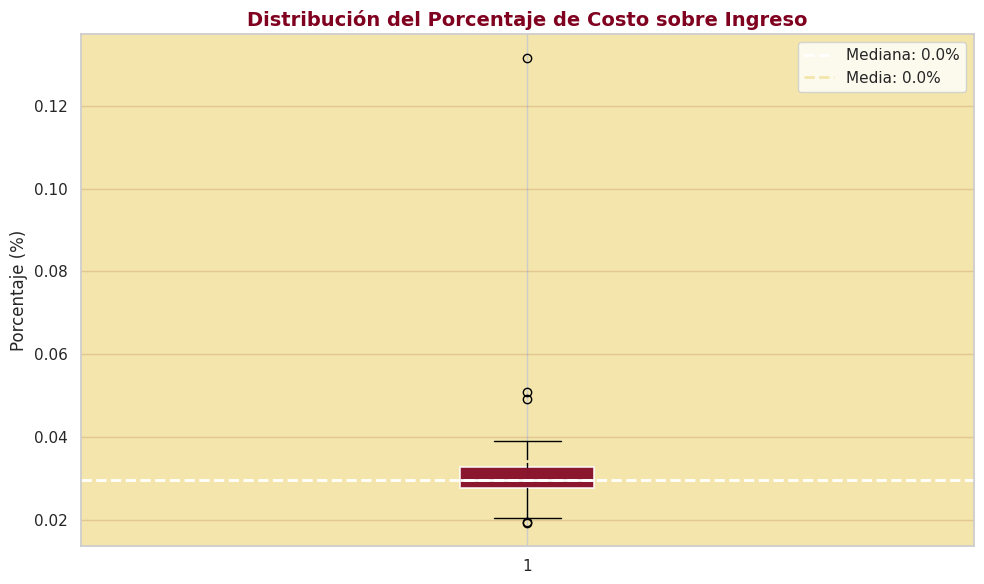

RESUMEN ESTADISTICO - PORCENTAJE COSTO/INGRESO
Productos analizados: 30
Media: 0.0%
Mediana: 0.0%
Minimo: 0.0%
Maximo: 0.1%
Desviacion estandar: 0.0%


In [641]:
###############(Dudas con las métricas) #################
# matplotlib.pyplot: Biblioteca fundamental para crear gráficos estáticos en Python
# Control granular sobre cada elemento del gráfico
# Base sobre la que se construyen otras bibliotecas
# Ideal para personalización avanzada

# seaborn: Biblioteca de visualización estadística built sobre matplotlib
# Gráficos más atractivos por defecto
# Sintaxis simplificada para gráficos complejos
# Integración nativa con DataFrames de pandas
# Paletas de colores profesionales

import matplotlib.pyplot as plt
import seaborn as sns

#CONFIGURACIÓN GLOBAL DE VISUALIZACIONES

PALETA_PRINCIPAL = {
    'bordo': '#800020',
    'vainilla': '#F3E5AB',
    'acento': '#A0522D'
}

# Configuración simple
plt.figure(figsize=(10, 6))

# Crear el boxplot con colores directos
boxplot = plt.boxplot(merged_df['porcentaje_costo_sobre_ingreso'],
                      vert=True,
                      patch_artist=True)  # Permite colorear la caja

# Colores usando la paleta
for box in boxplot['boxes']:
    box.set(facecolor=PALETA_PRINCIPAL['bordo'], alpha=0.9, edgecolor='white', linewidth=1.2)

for median in boxplot['medians']:
    median.set(color='white', linewidth=2)

plt.title('Distribución del Porcentaje de Costo sobre Ingreso',
          fontsize=14, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
plt.ylabel('Porcentaje (%)', fontsize=12)

# Estadísticas
mediana = merged_df['porcentaje_costo_sobre_ingreso'].median()
media = merged_df['porcentaje_costo_sobre_ingreso'].mean()

plt.axhline(y=mediana, color='white', linestyle='--', linewidth=2,
            label=f"Mediana: {mediana:.1f}%")
plt.axhline(y=media, color=PALETA_PRINCIPAL['vainilla'], linestyle='--', linewidth=2,
            label=f"Media: {media:.1f}%")

plt.legend()
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(axis='y', alpha=0.2, color=PALETA_PRINCIPAL['acento'])
plt.tight_layout()
plt.show()

# Resumen estadístico (se mantiene igual)
print("RESUMEN ESTADISTICO - PORCENTAJE COSTO/INGRESO")
print("=" * 50)
print(f"Productos analizados: {len(merged_df)}")
print(f"Media: {media:.1f}%")
print(f"Mediana: {mediana:.1f}%")
print(f"Minimo: {merged_df['porcentaje_costo_sobre_ingreso'].min():.1f}%")
print(f"Maximo: {merged_df['porcentaje_costo_sobre_ingreso'].max():.1f}%")
print(f"Desviacion estandar: {merged_df['porcentaje_costo_sobre_ingreso'].std():.1f}%")
print("=" * 50)

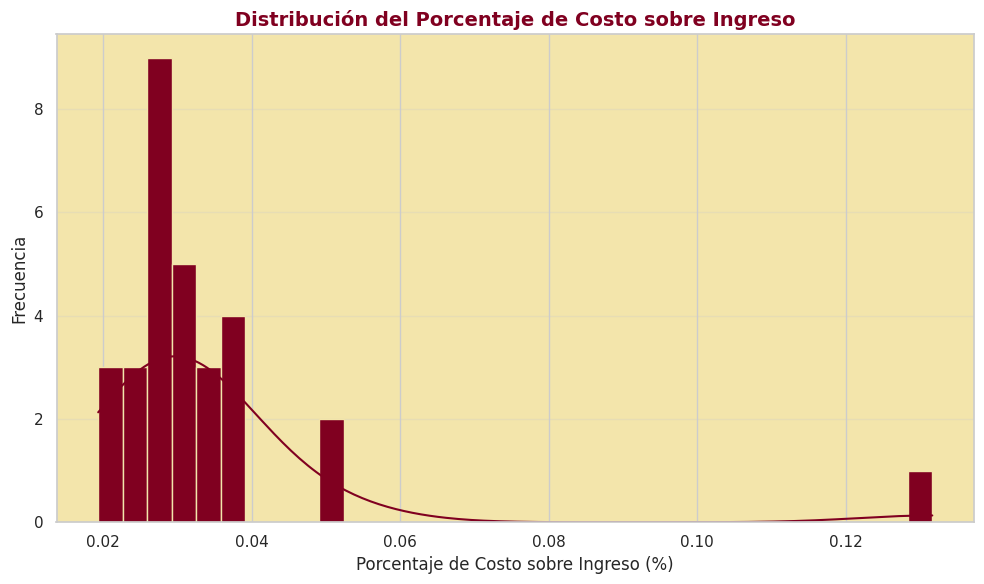

In [642]:
# Histograma para ver la distribución
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['porcentaje_costo_sobre_ingreso'],
             kde=True,
             color='#800020',
             alpha=1.0,
             edgecolor='#F3E5AB',
             linewidth=1)

plt.title('Distribución del Porcentaje de Costo sobre Ingreso',
          fontsize=14, fontweight='bold', color='#800020')
plt.xlabel('Porcentaje de Costo sobre Ingreso (%)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Color de fondo vainilla
plt.gca().set_facecolor('#F3E5AB')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##ETAPA 3: 1. Estadística Descriptiva: Calcular medidas de tendencia central y dispersión sobre las ventas. Presentar los resultados en un informe.


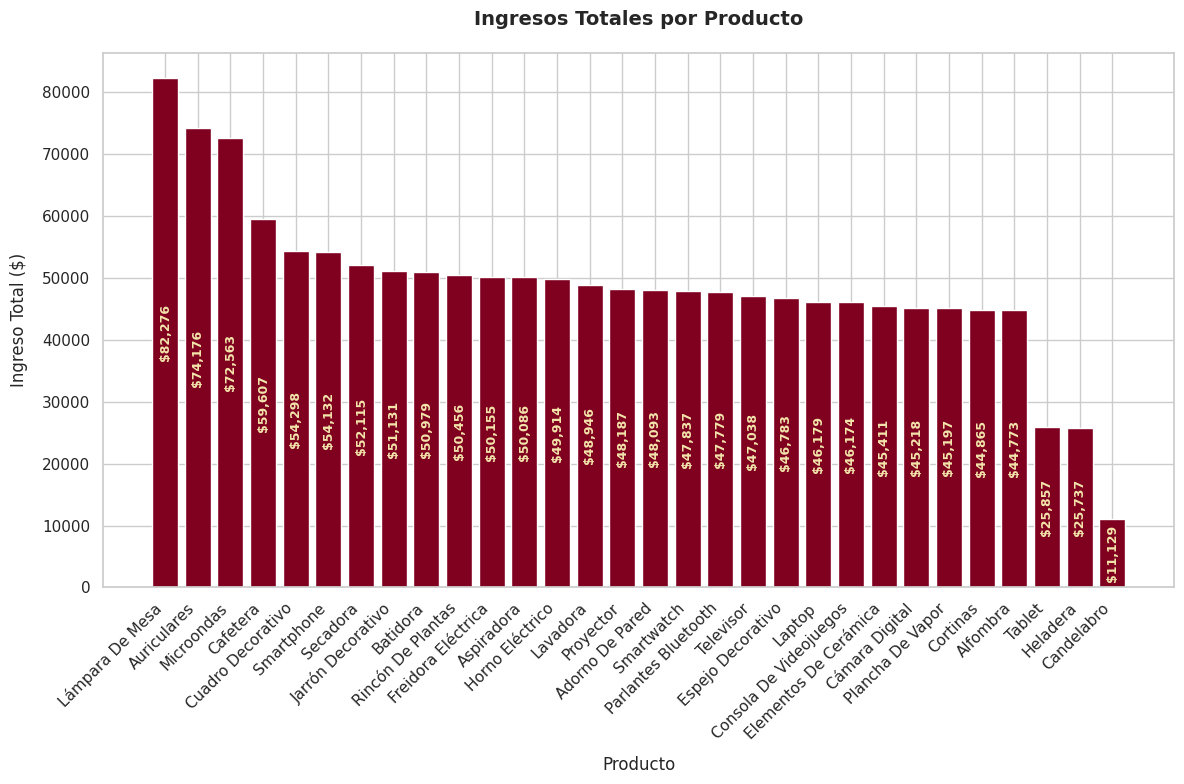

In [643]:
# el df que obtuvimos arriba resumen_prod, tiene un agrupado por producto con ingreso_total por producto, realizamos un grafico
#df = ventas_top.copy()
df = resumen_prod.copy()
#df = resumen_cant.copy()

# Importamos la librería de gráficos matplotlib
import matplotlib.pyplot as plt

# Ordenar datos para mejor visualización
df_ordenado = df.sort_values("ingreso_total", ascending=False)

# Configuración del gráfico
plt.figure(figsize=(12, 8))
barras = plt.bar(df_ordenado["producto"], df_ordenado["ingreso_total"],
                 color=PALETA_PRINCIPAL['bordo'])

# Personalización del gráfico
plt.title("Ingresos Totales por Producto", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Producto", fontsize=12, labelpad=10)
plt.ylabel("Ingreso Total ($)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')

# Etiquetas de valores en barras
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura / 2,
        f"${altura:,.0f}",
        ha='center',
        va='center',
        fontsize=9,
        color=PALETA_PRINCIPAL['vainilla'],
        rotation=90,
        fontweight='bold'
    )

# Ajuste final y visualización
plt.tight_layout()
plt.show()

##GRAFICO DE RESUMEN POR CATEGORIA

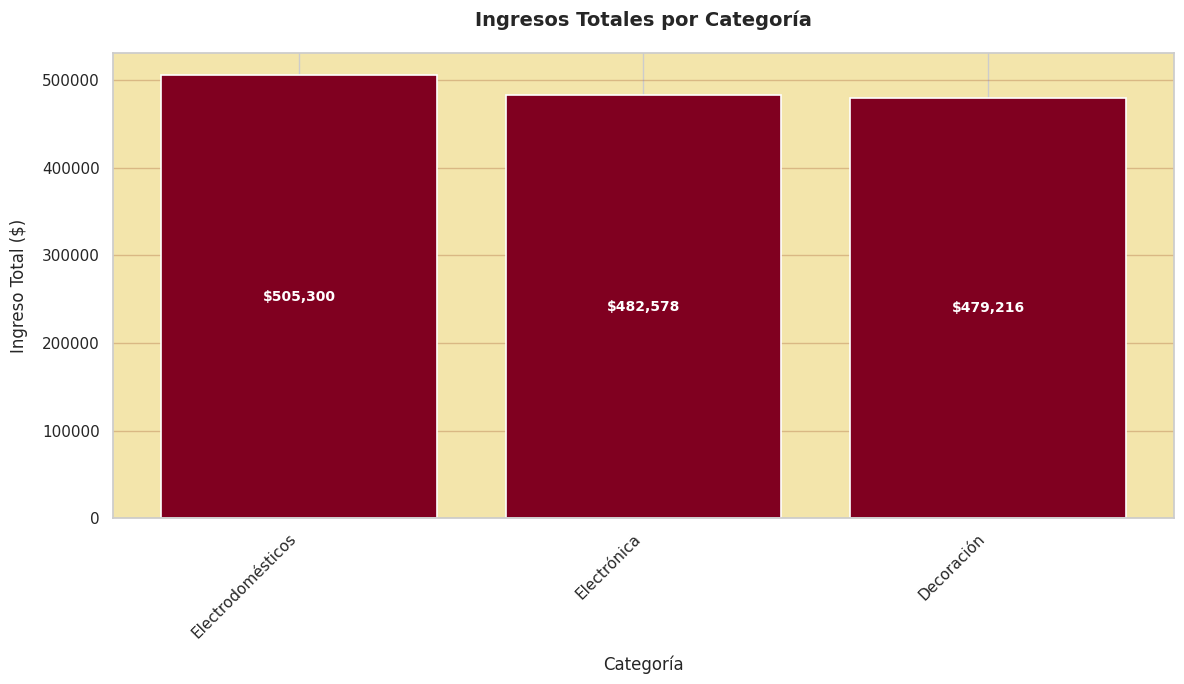

In [644]:
# Grafico de barras - Ingresos totales por categoria
df = resumen_cat.copy()

# Ordenar datos
df_ordenado = df.sort_values("ingreso_total", ascending=False)

# Configuración del gráfico
plt.figure(figsize=(12, 7))
barras = plt.bar(df_ordenado["categoria"], df_ordenado["ingreso_total"],
                 color=PALETA_PRINCIPAL['bordo'], edgecolor='white', linewidth=1.2)

# Personalización del gráfico
plt.title("Ingresos Totales por Categoría", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Categoría", fontsize=12, labelpad=10)
plt.ylabel("Ingreso Total ($)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)

# Etiquetas de valores en barras
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura / 2,
        f"${altura:,.0f}",
        ha='center',
        va='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

# Mejoras visuales
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(axis='y', alpha=0.3, color=PALETA_PRINCIPAL['acento'])

# Ajuste final y visualización
plt.tight_layout()
plt.show()

Medidas de tendencia central del Subtotal
Estas medidas describen el valor típico de las ventas:

Media: promedio general.
Mediana: valor central de los datos ordenados.
Moda: valor que más se repite.

In [645]:
# Medidas de tendencia central del Ingreso Total por Categoria
print("MEDIDAS DE TENDENCIA CENTRAL - INGRESO TOTAL POR CATEGORIA")
print("=" * 40)

# Cálculos básicos
media = df['ingreso_total'].mean()
mediana = df['ingreso_total'].median()
minimo = df['ingreso_total'].min()
maximo = df['ingreso_total'].max()

# Presentación simplificada
print(f"Media:   ${media:,.0f}")
print(f"Mediana: ${mediana:,.0f}")
print(f"Rango:   ${minimo:,.0f} - ${maximo:,.0f}")
print(f"Categorías: {len(df)}")

# Análisis de distribución
diferencia = abs(media - mediana)
if diferencia / media > 0.15:
    print("Distribución: Asimétrica")
else:
    print("Distribución: Balanceada")

MEDIDAS DE TENDENCIA CENTRAL - INGRESO TOTAL POR CATEGORIA
Media:   $489,031
Mediana: $482,578
Rango:   $479,216 - $505,300
Categorías: 3
Distribución: Balanceada


####Medidas de dispersión: Miden cuánto se alejan los valores entre sí:

####Rango = Máximo − Mínimo
####Varianza = Promedio de las desviaciones cuadradas
####Desviación estándar = Raíz cuadrada de la varianza

#### 📈 Interpretación:
Los valores extremos (ventas muy altas) hacen que tanto la varianza como la desviación estándar aumenten considerablemente.

#### ¿Qué es la desviación estándar?

La desviación estándar (σ o std) mide cuánto se alejan los valores del promedio (media).
Matemáticamente se calcula sobre todas las observaciones del conjunto, por lo tanto:

✅ Sí, incluye los outliers.

In [646]:
# Calculo de medidas de dispersion para multiples metricas
print("MEDIDAS DE DISPERSION - MULTIPLES METRICAS")
# Medidas de dispersión para métricas clave
print("MEDIDAS DE DISPERSIÓN")
print("=" * 30)

# Cálculos para cada métrica
rango_ingreso = df['ingreso_total'].max() - df['ingreso_total'].min()
desviacion_ingreso = df['ingreso_total'].std()

rango_cantidad = df['unidades'].max() - df['unidades'].min()
desviacion_cantidad = df['unidades'].std()

rango_precio = df['precio_promedio'].max() - df['precio_promedio'].min()
desviacion_precio = df['precio_promedio'].std()

# Resultados simplificados
print("\nINGRESO TOTAL:")
print(f"Rango:      ${rango_ingreso:,.0f}")
print(f"Desviación: ${desviacion_ingreso:,.0f}")

print("\nUNIDADES:")
print(f"Rango:      {rango_cantidad:,.0f} unidades")
print(f"Desviación: {desviacion_cantidad:,.0f} unidades")

print("\nPRECIO PROMEDIO:")
print(f"Rango:      ${rango_precio:,.2f}")
print(f"Desviación: ${desviacion_precio:,.2f}")

MEDIDAS DE DISPERSION - MULTIPLES METRICAS
MEDIDAS DE DISPERSIÓN

INGRESO TOTAL:
Rango:      $26,084
Desviación: $14,189

UNIDADES:
Rango:      179 unidades
Desviación: 90 unidades

PRECIO PROMEDIO:
Rango:      $2.42
Desviación: $1.21


In [647]:
# MEDIDAS ESTADÍSTICAS - RESUMEN COMPLETO

print("MEDIDAS ESTADÍSTICAS - RESUMEN COMPLETO")
print("=" * 50)

# Cálculo de medidas para ingreso_total
media_ingreso = df['ingreso_total'].mean()
mediana_ingreso = df['ingreso_total'].median()
desviacion_ingreso = df['ingreso_total'].std(ddof=1)
rango_ingreso = df['ingreso_total'].max() - df['ingreso_total'].min()

# Presentación de resultados
print("\nINGRESO TOTAL:")
print(f"• Media:          ${media_ingreso:>12,.2f}")
print(f"• Mediana:        ${mediana_ingreso:>12,.2f}")
print(f"• Desviación:     ${desviacion_ingreso:>12,.2f}")
print(f"• Rango:          ${rango_ingreso:>12,.2f}")

# Cálculo de coeficiente de variación para contexto adicional
coef_variacion_ingreso = (desviacion_ingreso / media_ingreso) * 100
print(f"• Coef. Variación: {coef_variacion_ingreso:>11.1f}%")

# Resumen interpretativo
print("\n" + "-" * 50)
print("INTERPRETACIÓN:")
if coef_variacion_ingreso < 30:
    print("• Baja variabilidad en los ingresos")
elif coef_variacion_ingreso < 60:
    print("• Variabilidad moderada en los ingresos")
else:
    print("• Alta variabilidad en los ingresos")

if abs(media_ingreso - mediana_ingreso) / media_ingreso < 0.1:
    print("• Distribución relativamente simétrica")
else:
    print("• Distribución asimétrica (presencia de valores extremos)")

MEDIDAS ESTADÍSTICAS - RESUMEN COMPLETO

INGRESO TOTAL:
• Media:          $  489,031.17
• Mediana:        $  482,577.80
• Desviación:     $   14,188.81
• Rango:          $   26,083.54
• Coef. Variación:         2.9%

--------------------------------------------------
INTERPRETACIÓN:
• Baja variabilidad en los ingresos
• Distribución relativamente simétrica


### Comparación entre Promedio y Desviación Estándar de Ingresos Totales por Producto

**Valores Obtenidos:**
- **Media (Promedio):** 48,903.12

- **Mediana:** 48,140.24

- **Desviación Estándar:** 13,265.56

- **Rango:** 71,147.58 (Máximo 82,276.38 - Mínimo 11,128.80)

**Análisis:**

1.  **Media vs. Mediana:**

    El promedio= 48,903.12 y la mediana= 48,140.24 son valores muy cercanos. Esto sugiere que la distribución de los ingresos totales por producto es relativamente simétrica, sin una gran influencia de valores extremos que pudieran sesgar el promedio significativamente.

2.  **Desviación Estándar:**

    La desviación estándar de 13,265.56 indica la dispersión promedio de los ingresos de cada producto con respecto a la media. En relación con la media de $48,903.12, esta desviación es considerable (aproximadamente un 27% de la media).

3.  **Rango:**
    El rango de 71,147.58, que va desde el producto con menores ingresos (11,128.80) hasta el de mayores ingresos (82,276.38), confirma una amplia variabilidad entre los productos.

**Conclusión:**

  Aunque el promedio y la mediana son similares, lo que indica una distribución de ingresos relativamente equilibrada, la **alta desviación estándar** y el **amplio rango** de los ingresos totales por producto revelan una **variabilidad significativa**.

  Esto significa que no todos los productos generan ingresos de manera uniforme. Existen productos con un rendimiento muy superior y otros con un rendimiento considerablemente inferior. Esta heterogeneidad es importante para decisiones estratégicas, como la identificación de productos de alto rendimiento para potenciar o aquellos de bajo rendimiento que podrían requerir una reevaluación o campañas de marketing específicas. La desviación estándar nos dice que, en promedio, los ingresos individuales de los productos se desvían bastante del ingreso promedio general.

In [648]:
# Comparacion entre Promedio y Desviacion Estandar de Ingresos Totales por Categoria

print("ANALISIS COMPARATIVO - MEDIDAS DE TENDENCIA CENTRAL Y DISPERSION")
print("=" * 65)

# Valores obtenidos (estos vendrian de calculos previos)
media = 48903.12
mediana = 48140.24
desviacion_estandar = 13265.56
rango = 71147.58
minimo = 11128.80
maximo = 82276.38
coef_variacion = (desviacion_estandar / media) * 100

print("VALORES OBTENIDOS:")
print(f"• Media (Promedio):    ${media:>12,.2f}")
print(f"• Mediana:             ${mediana:>12,.2f}")
print(f"• Desviacion estandar: ${desviacion_estandar:>12,.2f}")
print(f"• Rango:               ${rango:>12,.2f}")
print(f"• Minimo:              ${minimo:>12,.2f}")
print(f"• Maximo:              ${maximo:>12,.2f}")
print(f"• Coef. variacion:     {coef_variacion:>12.1f}%")

print("\n" + "-" * 65)
print("ANALISIS ESTADISTICO:")

# Analisis de simetria
diferencia_media_mediana = abs(media - mediana)
if diferencia_media_mediana < (media * 0.05):  # Menos del 5% de diferencia
    simetria = "distribucion simetrica"
elif media > mediana:
    simetria = "sesgo positivo leve"
else:
    simetria = "sesgo negativo leve"

print(f"1. SIMETRIA: {simetria}")
print(f"   - Diferencia media-mediana: ${diferencia_media_mediana:,.2f} ({diferencia_media_mediana/media*100:.1f}%)")

# Analisis de dispersion
print(f"2. DISPERSION: { 'Alta' if coef_variacion > 30 else 'Moderada' if coef_variacion > 15 else 'Baja' }")
print(f"   - La desviacion estandar representa el {coef_variacion:.1f}% de la media")
print(f"   - Rango amplio: ${rango:,.2f} ({minimo/maximo*100:.1f}% a {maximo/minimo*100:.1f}% del maximo)")

# Analisis de variabilidad
print("3. VARIABILIDAD:")
print("   - Existe heterogeneidad significativa en el rendimiento por categoria")
print("   - Algunas categorias generan ingresos muy superiores al promedio")
print("   - Otras categorias tienen rendimiento considerablemente inferior")

print("\n" + "-" * 65)
print("CONCLUSIONES ESTRATEGICAS:")
print("• La distribucion es relativamente equilibrada pero con alta variabilidad")
print("• Se recomienda identificar categorias de alto rendimiento para potenciar")
print("• Categorias de bajo rendimiento requieren reevaluacion estrategica")
print("• La desviacion del {:.1f}% indica necesidad de segmentacion en el analisis".format(coef_variacion))

ANALISIS COMPARATIVO - MEDIDAS DE TENDENCIA CENTRAL Y DISPERSION
VALORES OBTENIDOS:
• Media (Promedio):    $   48,903.12
• Mediana:             $   48,140.24
• Desviacion estandar: $   13,265.56
• Rango:               $   71,147.58
• Minimo:              $   11,128.80
• Maximo:              $   82,276.38
• Coef. variacion:             27.1%

-----------------------------------------------------------------
ANALISIS ESTADISTICO:
1. SIMETRIA: distribucion simetrica
   - Diferencia media-mediana: $762.88 (1.6%)
2. DISPERSION: Moderada
   - La desviacion estandar representa el 27.1% de la media
   - Rango amplio: $71,147.58 (13.5% a 739.3% del maximo)
3. VARIABILIDAD:
   - Existe heterogeneidad significativa en el rendimiento por categoria
   - Algunas categorias generan ingresos muy superiores al promedio
   - Otras categorias tienen rendimiento considerablemente inferior

-----------------------------------------------------------------
CONCLUSIONES ESTRATEGICAS:
• La distribucion es rel

## Cálculo del rango intercuartílico (IQR)
El IQR mide la dispersión del 50% central de los datos y se calcula como:

[ IQR = Q3 - Q1 ]

Es menos sensible a los outliers.

✅ Interpretación:
El IQR refleja el rango donde se encuentran las ventas normales, sin verse afectado por los outliers.

In [649]:
# Calculo del rango intercuartilico (IQR) - Ingreso Total por Categoria
print("RANGO INTERCUARTILICO (IQR) - INGRESO TOTAL POR CATEGORIA")
print("=" * 55)

# Calculo de quartiles e IQR
q1 = df['ingreso_total'].quantile(0.25)
q2 = df['ingreso_total'].quantile(0.5)  # Mediana
q3 = df['ingreso_total'].quantile(0.75)
iqr = q3 - q1

# Presentacion de resultados
print(f"Q1 (Percentil 25):   ${q1:>15,.2f}")
print(f"Mediana (Q2):        ${q2:>15,.2f}")
print(f"Q3 (Percentil 75):   ${q3:>15,.2f}")
print(f"IQR (Q3 - Q1):       ${iqr:>15,.2f}")

# Calculo de limites para deteccion de outliers
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Limite inferior:     ${limite_inferior:>15,.2f}")
print(f"Limite superior:     ${limite_superior:>15,.2f}")

# Deteccion de outliers
outliers_inferiores = df[df['ingreso_total'] < limite_inferior]
outliers_superiores = df[df['ingreso_total'] > limite_superior]

print("\n" + "-" * 55)
print("DETECCION DE OUTLIERS:")
print(f"Outliers inferiores: {len(outliers_inferiores)} categorias")
print(f"Outliers superiores: {len(outliers_superiores)} categorias")

if len(outliers_superiores) > 0:
    print("\nCategorias con ingresos excepcionalmente altos:")
    for _, cat in outliers_superiores.iterrows():
        print(f"• {cat['categoria']}: ${cat['ingreso_total']:,.2f}")

if len(outliers_inferiores) > 0:
    print("\nCategorias con ingresos excepcionalmente bajos:")
    for _, cat in outliers_inferiores.iterrows():
        print(f"• {cat['categoria']}: ${cat['ingreso_total']:,.2f}")

print("\n" + "-" * 55)
print("INTERPRETACION:")
print(f"• El 50% central de categorias tiene ingresos entre ${q1:,.2f} y ${q3:,.2f}")
print(f"• El IQR de ${iqr:,.2f} representa la dispersion del segmento medio")
print("• Metodo robusto: menos sensible a valores extremos que el rango total")
print("• Los limites definen el rango esperado para ingresos 'normales'")

RANGO INTERCUARTILICO (IQR) - INGRESO TOTAL POR CATEGORIA
Q1 (Percentil 25):   $     480,896.95
Mediana (Q2):        $     482,577.80
Q3 (Percentil 75):   $     493,938.71
IQR (Q3 - Q1):       $      13,041.77
Limite inferior:     $     461,334.29
Limite superior:     $     513,501.37

-------------------------------------------------------
DETECCION DE OUTLIERS:
Outliers inferiores: 0 categorias
Outliers superiores: 0 categorias

-------------------------------------------------------
INTERPRETACION:
• El 50% central de categorias tiene ingresos entre $480,896.95 y $493,938.71
• El IQR de $13,041.77 representa la dispersion del segmento medio
• Metodo robusto: menos sensible a valores extremos que el rango total
• Los limites definen el rango esperado para ingresos 'normales'


## Detección de outliers usando el IQR
Regla general:

Límite inferior = Q1 − (1.5 × IQR)

Límite superior = Q3 + (1.5 × IQR)

In [650]:
# Deteccion de outliers usando el metodo del rango intercuartilico
print("DETECCION DE OUTLIERS - METODO IQR")
print("=" * 50)

# Calculo de limites
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# Deteccion de outliers
outliers = df[(df['ingreso_total'] < lim_inf) | (df['ingreso_total'] > lim_sup)]

# Presentacion de resultados
print(f"Limite inferior: ${lim_inf:>15,.2f}")
print(f"Limite superior: ${lim_sup:>15,.2f}")
print(f"\nOutliers detectados: {len(outliers)} de {len(df)} categorias ({len(outliers)/len(df)*100:.1f}%)")

if len(outliers) > 0:
    print("\nCATEGORIAS CON VALORES ATIPICOS:")
    print("-" * 40)

    # Formatear la salida de outliers
    for _, outlier in outliers.iterrows():
        tipo = "INFERIOR" if outlier['ingreso_total'] < lim_inf else "SUPERIOR"
        diferencia = lim_inf - outlier['ingreso_total'] if tipo == "INFERIOR" else outlier['ingreso_total'] - lim_sup

        print(f"Categoria: {outlier['categoria']}")
        print(f"  Ingreso: ${outlier['ingreso_total']:,.2f} ({tipo})")
        print(f"  Desviacion: ${diferencia:,.2f} del limite")
        print(f"  Unidades: {outlier['unidades']:,}")
        print(f"  Precio promedio: ${outlier['precio_promedio']:,.2f}")
        print()
else:
    print("\nNo se detectaron valores atipicos")

# Resumen del impacto
print("=" * 50)
print("RESUMEN DEL IMPACTO:")
if len(outliers) > 0:
    ingreso_total_outliers = outliers['ingreso_total'].sum()
    ingreso_total_dataset = df['ingreso_total'].sum()
    porcentaje_impacto = (ingreso_total_outliers / ingreso_total_dataset) * 100

    print(f"• Los outliers representan el {porcentaje_impacto:.1f}% del ingreso total")
    print(f"• Ingreso en outliers: ${ingreso_total_outliers:,.2f}")
    print(f"• Ingreso total dataset: ${ingreso_total_dataset:,.2f}")

    # Recomendaciones basadas en los resultados
    if len(outliers) / len(df) > 0.2:  # Si mas del 20% son outliers
        print("• ALERTA: Alta proporcion de valores atipicos")
    else:
        print("• Proporcion normal de valores atipicos")
else:
    print("• No hay impacto significativo de valores atipicos")
    print("• La distribucion de ingresos es homogenea")

DETECCION DE OUTLIERS - METODO IQR
Limite inferior: $     461,334.29
Limite superior: $     513,501.37

Outliers detectados: 0 de 3 categorias (0.0%)

No se detectaron valores atipicos
RESUMEN DEL IMPACTO:
• No hay impacto significativo de valores atipicos
• La distribucion de ingresos es homogenea


##ETAPA 3: 2. Análisis Exploratorio de Datos (EDA): Realizar un análisis exploratorio utilizando visualizaciones para identificar patrones y tendencias en las ventas.

Buscamos patrones y tendencias en las ventas usando visualizaciones simples. A continuación se muestran un histograma (distribución) y un boxplot (dispersión/outliers) sobre los ingresos por producto ya calculados en etapas previas.

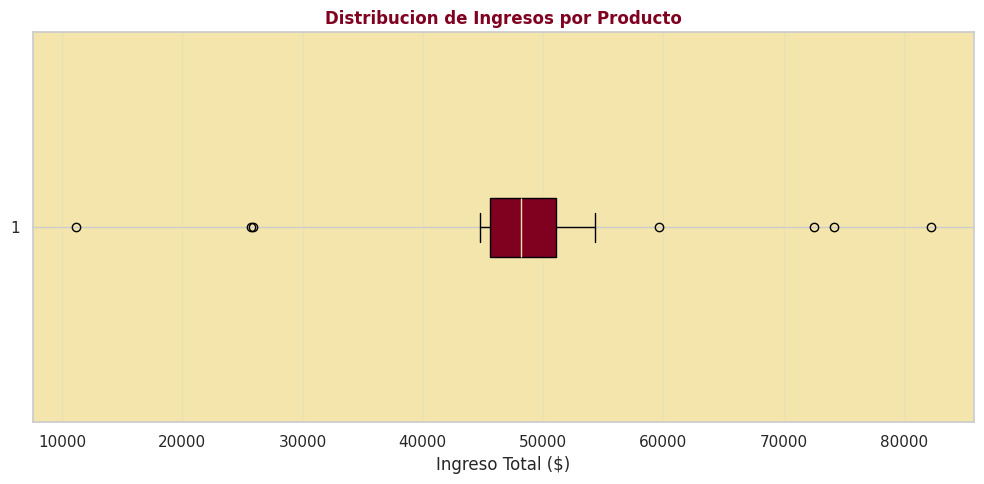

Productos: 30, Media: $48,903, Mediana: $48,140


In [651]:
# Boxplot: Distribucion de ingresos por producto
vals = resumen_prod['ingreso_total'].dropna()

plt.figure(figsize=(10, 5))
boxplot = plt.boxplot(vals, vert=False, patch_artist=True)

# Aplicar paleta de colores
boxplot['boxes'][0].set_facecolor(PALETA_PRINCIPAL['bordo'])
boxplot['medians'][0].set_color(PALETA_PRINCIPAL['vainilla'])

plt.title('Distribucion de Ingresos por Producto',
          fontsize=12, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
plt.xlabel('Ingreso Total ($)')
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

# Resumen breve
print(f"Productos: {len(vals)}, Media: ${vals.mean():,.0f}, Mediana: ${vals.median():,.0f}")

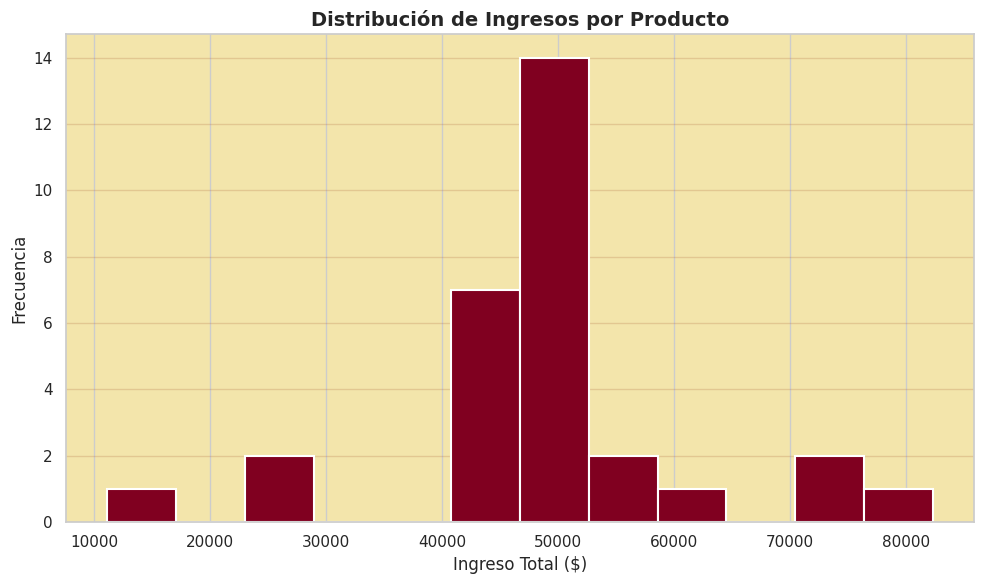

In [652]:
# HISTOGRAMA: DISTRIBUCIÓN DE INGRESO_TOTAL

import matplotlib.pyplot as plt

# Aplicar paleta principal al histograma
serie = resumen_prod['ingreso_total']

plt.figure(figsize=(10, 6))
plt.hist(serie, bins=12, color=PALETA_PRINCIPAL['bordo'],
         alpha=1.0, edgecolor='white', linewidth=1.5)
plt.title('Distribución de Ingresos por Producto', fontsize=14, fontweight='bold')
plt.xlabel('Ingreso Total ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.2, color=PALETA_PRINCIPAL['acento'])
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.tight_layout()
plt.show()

##Etapa 3: 3 Correlación
Evaluamos la relación entre precio_promedio y unidades por producto. Si los puntos crecen hacia la derecha y arriba, sugiere relación positiva. También mostramos el coeficiente de correlación.

ANALISIS DE DISPERSION - PRECIO PROMEDIO VS UNIDADES


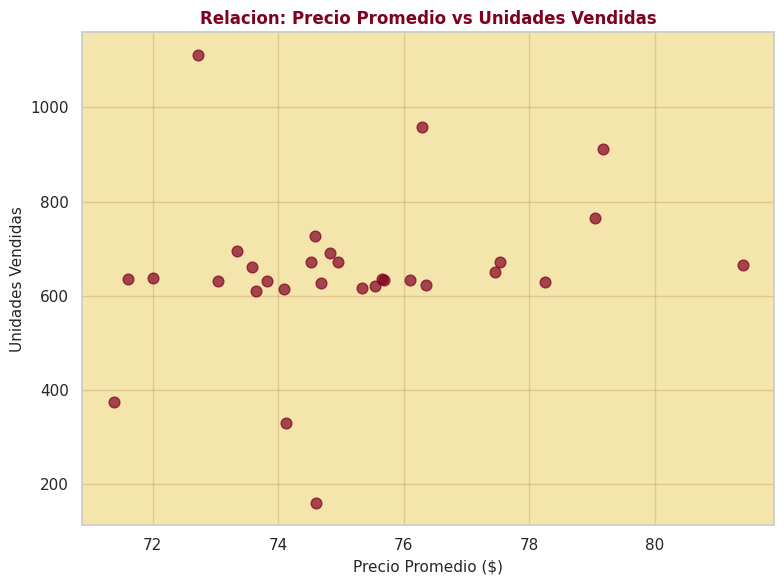

Coeficiente de correlacion: 0.217
Relacion: debil y positiva


In [653]:
# Dispersion: Precio promedio vs Unidades por producto
print("ANALISIS DE DISPERSION - PRECIO PROMEDIO VS UNIDADES")
print("=" * 50)

x = resumen_prod['precio_promedio']
y = resumen_prod['unidades']

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color=PALETA_PRINCIPAL['bordo'], alpha=0.7, s=60)

plt.title('Relacion: Precio Promedio vs Unidades Vendidas',
          fontsize=12, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
plt.xlabel('Precio Promedio ($)', fontsize=11)
plt.ylabel('Unidades Vendidas', fontsize=11)

plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(alpha=0.2, color=PALETA_PRINCIPAL['acento'])

plt.tight_layout()
plt.show()

# Calculo e interpretacion de correlacion
correlacion = x.corr(y)
print(f"Coeficiente de correlacion: {correlacion:.3f}")

if abs(correlacion) > 0.7:
    fuerza = "fuerte"
elif abs(correlacion) > 0.3:
    fuerza = "moderada"
else:
    fuerza = "debil"

signo = "positiva" if correlacion > 0 else "negativa"
print(f"Relacion: {fuerza} y {signo}")


# Analisis de correlacion: Precio promedio vs Unidades por producto



### 4.1 Visualización con Matplotlib (básica)
Gráficos de **líneas, barras y dispersión** comentados línea por línea.


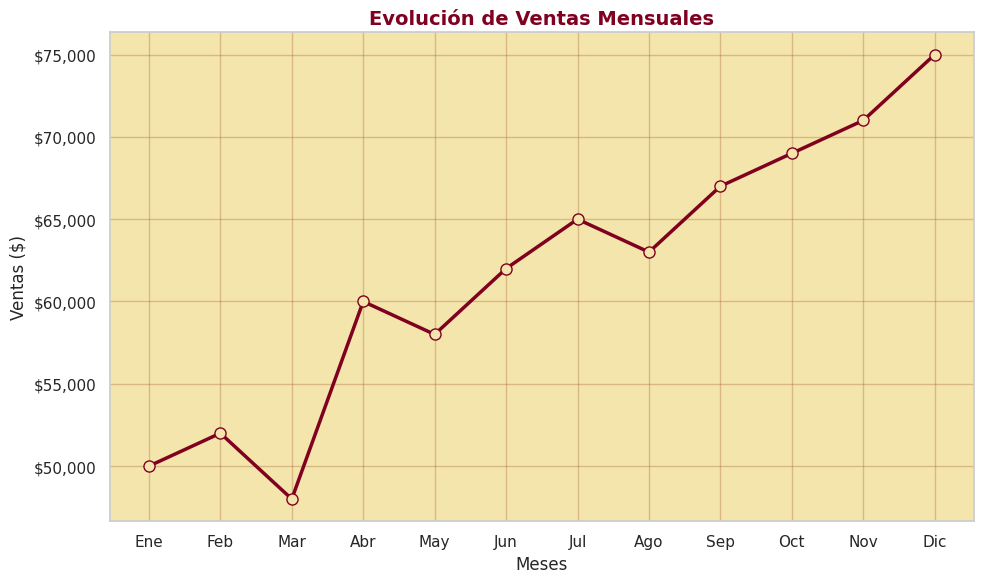

RESUMEN EVOLUCIÓN VENTAS
Crecimiento: +50.0%
Mes pico: Dic
Promedio mensual: $61,667


<Figure size 640x480 with 0 Axes>

RESUMEN EVOLUCION VENTAS
Crecimiento: +50.0%
Mes pico: Dic
Promedio mensual: $61,667


In [654]:
# GRAFICO DE LINEAS - EVOLUCION TEMPORAL
# ======================================

# Crear datos de meses si no existen
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
# Asegurar que ventas_mensuales tenga la misma longitud
if 'ventas_mensuales' not in locals() or len(ventas_mensuales) != len(meses):
    print("Advertencia: Creando datos de ventas mensuales de ejemplo")
    ventas_mensuales = [50000, 52000, 48000, 60000, 58000, 62000, 65000, 63000, 67000, 69000, 71000, 75000]

# Configurar figura
plt.figure(figsize=(10, 6))

# Crear gráfico de líneas simplificado
plt.plot(meses, ventas_mensuales,
         color=PALETA_PRINCIPAL['bordo'],
         linewidth=2.5,
         marker='o',
         markersize=8,
         markerfacecolor=PALETA_PRINCIPAL['vainilla'],
         markeredgecolor=PALETA_PRINCIPAL['bordo'])

# Título y etiquetas
plt.title('Evolución de Ventas Mensuales',
          fontsize=14, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
plt.xlabel('Meses', fontsize=12)
plt.ylabel('Ventas ($)', fontsize=12)

# Configurar fondo y grid
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(alpha=0.3, color=PALETA_PRINCIPAL['acento'])

# Formatear eje Y con separadores de miles
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Ajustar layout
plt.tight_layout()
plt.show()

# Análisis conciso
print("RESUMEN EVOLUCIÓN VENTAS")
print("=" * 40)
print(f"Crecimiento: {((ventas_mensuales[-1] - ventas_mensuales[0]) / ventas_mensuales[0] * 100):+.1f}%")
print(f"Mes pico: {meses[ventas_mensuales.index(max(ventas_mensuales))]}")
print(f"Promedio mensual: ${sum(ventas_mensuales)/len(ventas_mensuales):,.0f}")


# Ajustar layout
plt.tight_layout()
plt.show()

# Análisis conciso
print("RESUMEN EVOLUCION VENTAS")
print("=" * 40)
print(f"Crecimiento: {((ventas_mensuales[-1] - ventas_mensuales[0]) / ventas_mensuales[0] * 100):+.1f}%")
print(f"Mes pico: {meses[ventas_mensuales.index(max(ventas_mensuales))]}")
print(f"Promedio mensual: ${sum(ventas_mensuales)/len(ventas_mensuales):,.0f}")

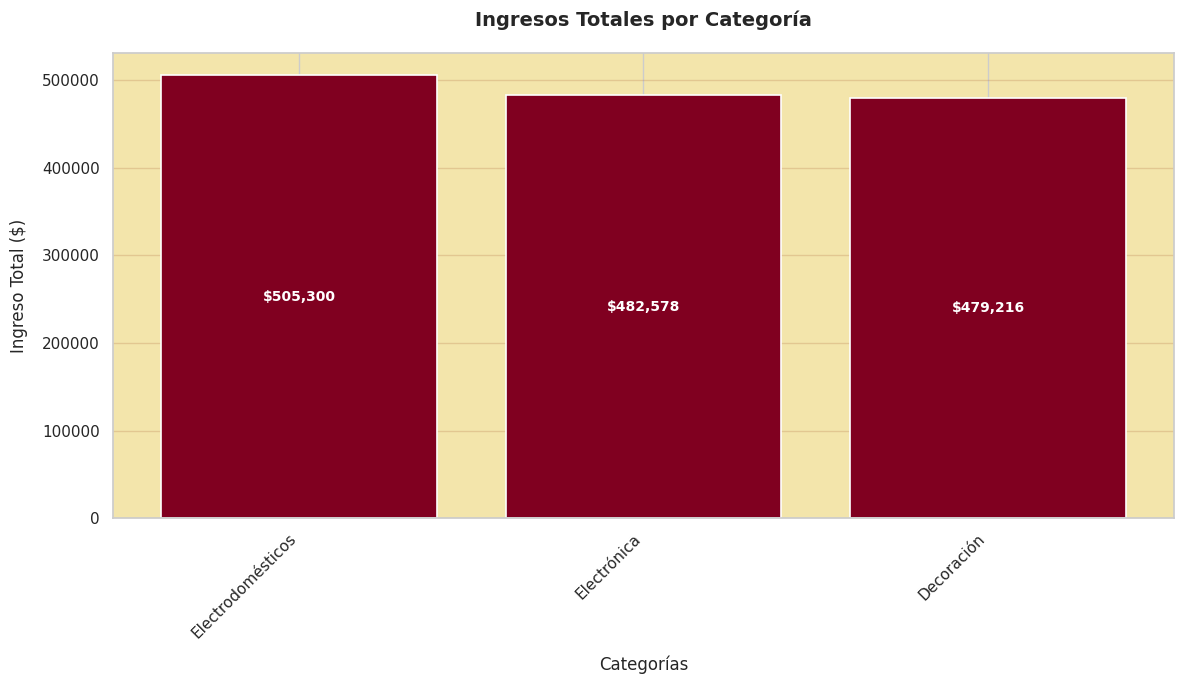

In [655]:
# GRAFICO DE BARRAS - COMPARACION POR CATEGORIA

# Usar datos del resumen por categoría
categorias = resumen_cat['categoria']
ingresos = resumen_cat['ingreso_total']

# Ordenar datos para mejor visualización
df_ordenado = resumen_cat.sort_values('ingreso_total', ascending=False)
categorias_ordenadas = df_ordenado['categoria']
ingresos_ordenados = df_ordenado['ingreso_total']

# Configurar figura
plt.figure(figsize=(12, 7))

# Crear gráfico de barras con colores optimizados
barras = plt.bar(categorias_ordenadas, ingresos_ordenados,
                 color=PALETA_PRINCIPAL['bordo'],  # Color sólido
                 alpha=1.0,                        # Sin transparencia
                 edgecolor='white',                # Borde blanco para mejor definición
                 linewidth=1.2)                    # Grosor del borde

# Personalizar título y ejes
plt.title('Ingresos Totales por Categoría',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Categorías', fontsize=12, labelpad=10)
plt.ylabel('Ingreso Total ($)', fontsize=12, labelpad=10)

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras - MEJOR CONTRASTE
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura/2,
             f'${altura:,.0f}',
             ha='center',
             va='center',
             fontsize=10,
             color='white',           # Texto blanco para máximo contraste
             fontweight='bold')       # Negrita para mejor legibilidad

# Configurar fondo y grid
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(axis='y', alpha=0.2, color=PALETA_PRINCIPAL['acento'])

# Ajustar layout
plt.tight_layout()
plt.show()

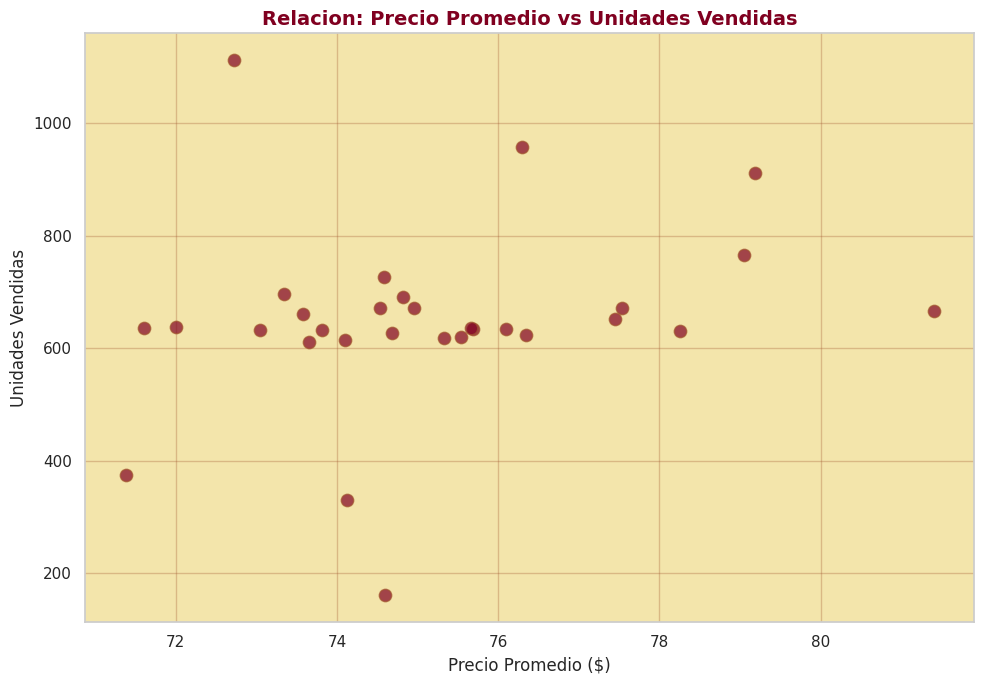

Coeficiente de correlacion: 0.217


In [656]:
# GRAFICO DE DISPERSION - RELACION ENTRE VARIABLES
# ================================================

# Configurar figura
plt.figure(figsize=(10, 7))

# Crear gráfico de dispersión
plt.scatter(resumen_prod['precio_promedio'],  # Valores eje X
            resumen_prod['unidades'],         # Valores eje Y
            color=PALETA_PRINCIPAL['bordo'],  # Color de puntos
            alpha=0.7,                        # Transparencia
            s=80,                             # Tamaño de puntos
            edgecolors=PALETA_PRINCIPAL['acento'],  # Color del borde
            linewidths=1)                     # Grosor del borde

# Personalizar título y ejes
plt.title('Relacion: Precio Promedio vs Unidades Vendidas',
          fontsize=14, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
plt.xlabel('Precio Promedio ($)', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)

# Configurar fondo y grid
plt.gca().set_facecolor(PALETA_PRINCIPAL['vainilla'])
plt.grid(alpha=0.3, color=PALETA_PRINCIPAL['acento'])

# Agregar línea de tendencia si hay correlación significativa
correlacion = resumen_prod['precio_promedio'].corr(resumen_prod['unidades'])
if abs(correlacion) > 0.3:
    z = np.polyfit(resumen_prod['precio_promedio'], resumen_prod['unidades'], 1)
    p = np.poly1d(z)
    plt.plot(resumen_prod['precio_promedio'], p(resumen_prod['precio_promedio']),
             color=PALETA_PRINCIPAL['acento'], linewidth=2, linestyle='--',
             label=f'Tendencia (r = {correlacion:.2f})')
    plt.legend()

# Ajustar layout
plt.tight_layout()
plt.show()

# Mostrar estadística de correlación
print(f"Coeficiente de correlacion: {correlacion:.3f}")

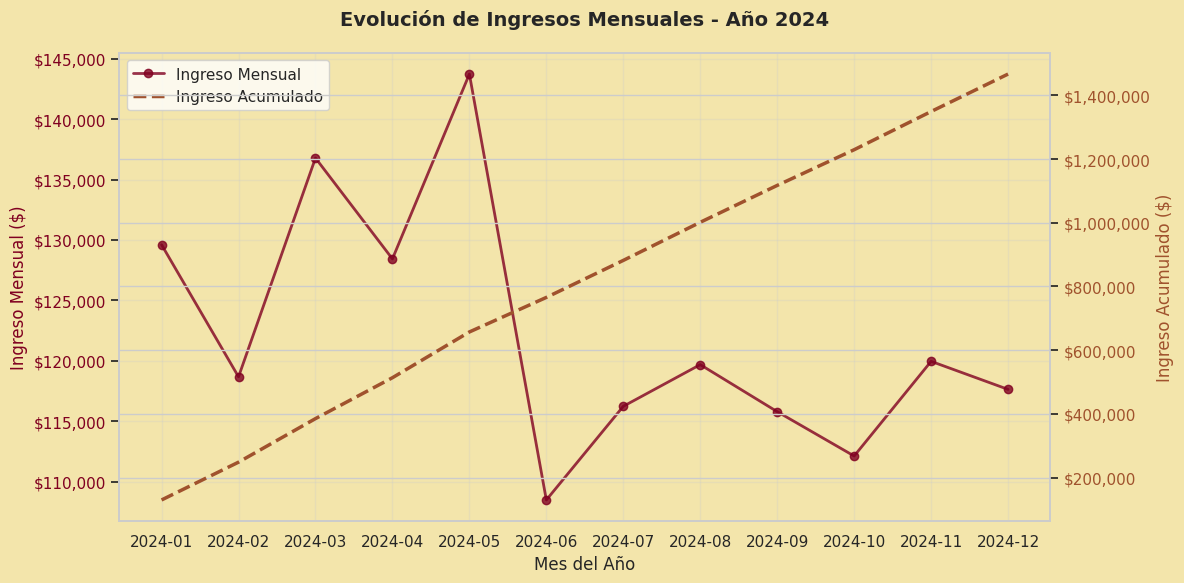

RESUMEN DE TENDENCIA MENSUAL
Año analizado: 2024
Meses analizados: 12
Ingreso total anual: $1,467,094
Promedio mensual: $122,258
Mejor mes: 2024-05 ($143,727)
Crecimiento anual: 1032.0%


In [657]:
# Tendencia de ingresos mensual a lo largo del tiempo
ventas_perf['fecha_venta'] = pd.to_datetime(ventas_perf['fecha_venta'], errors='coerce')

# Agrupar por mes y año
ventas_perf['año_mes'] = ventas_perf['fecha_venta'].dt.to_period('M')
ingresos_por_mes = ventas_perf.groupby('año_mes')['ingreso'].sum()
ingresos_acumulados_mes = ingresos_por_mes.cumsum()

# Obtener el año para el título
año_actual = ventas_perf['fecha_venta'].dt.year.max()

# Crear figura con dos ejes Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje principal - Ingresos mensuales
color_mensual = PALETA_PRINCIPAL['bordo']
ax1.set_xlabel('Mes del Año', fontsize=12)
ax1.set_ylabel('Ingreso Mensual ($)', fontsize=12, color=color_mensual)
line1 = ax1.plot(ingresos_por_mes.index.astype(str), ingresos_por_mes.values,
                color=color_mensual, alpha=0.8, linewidth=2, marker='o',
                markersize=6, label='Ingreso Mensual')
ax1.tick_params(axis='y', labelcolor=color_mensual)
ax1.grid(True, alpha=0.3)

# Eje secundario - Ingresos acumulados
ax2 = ax1.twinx()
color_acumulado = PALETA_PRINCIPAL['acento']
ax2.set_ylabel('Ingreso Acumulado ($)', fontsize=12, color=color_acumulado)
line2 = ax2.plot(ingresos_acumulados_mes.index.astype(str), ingresos_acumulados_mes.values,
                color=color_acumulado, linewidth=2.5, linestyle='--',
                label='Ingreso Acumulado')
ax2.tick_params(axis='y', labelcolor=color_acumulado)

# Título con el año
plt.title(f'Evolución de Ingresos Mensuales - Año {año_actual}',
          fontsize=14, fontweight='bold', pad=20)

# Combinar leyendas
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

# Fondo
fig.patch.set_facecolor(PALETA_PRINCIPAL['vainilla'])
ax1.set_facecolor(PALETA_PRINCIPAL['vainilla'])

# Formatear ejes
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Métricas clave
print("RESUMEN DE TENDENCIA MENSUAL")
print("=" * 45)
print(f"Año analizado: {año_actual}")
print(f"Meses analizados: {len(ingresos_por_mes)}")
print(f"Ingreso total anual: ${ingresos_acumulados_mes.iloc[-1]:,.0f}")
print(f"Promedio mensual: ${ingresos_por_mes.mean():,.0f}")
print(f"Mejor mes: {ingresos_por_mes.idxmax()} (${ingresos_por_mes.max():,.0f})")
print(f"Crecimiento anual: {((ingresos_acumulados_mes.iloc[-1] - ingresos_acumulados_mes.iloc[0]) / ingresos_acumulados_mes.iloc[0] * 100):.1f}%")


### 4.2 Visualización Avanzada con Seaborn
Seaborn ofrece estilos y elementos estadísticos que mejoran la presentación.


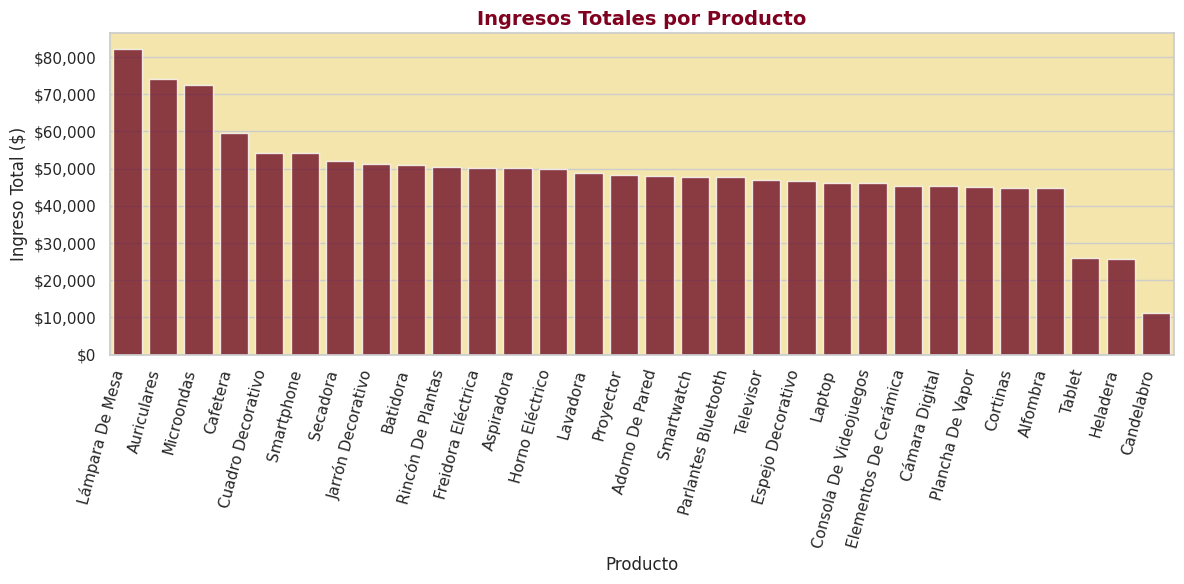

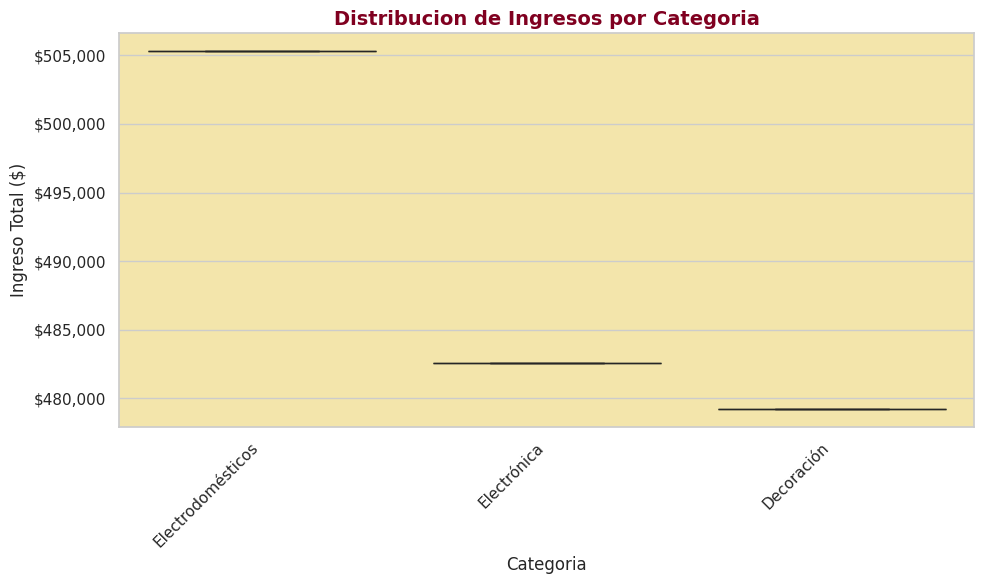

RESUMEN VISUALIZACION - SEABORN
Productos analizados: 30
Categorias analizadas: 3
Rango de ingresos productos: $11,129 - $82,276
Rango de ingresos categorias: $479,216 - $505,300


In [658]:
# Seaborn: Graficos de barras ordenadas y boxplot por categoria
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar estilo de seaborn
sns.set_theme(style="whitegrid")

# Grafico de barras ordenadas
df = resumen_prod.sort_values('ingreso_total', ascending=False)
plt.figure(figsize=(12, 6))

# Crear grafico de barras con paleta personalizada
ax = sns.barplot(data=df, x='producto', y='ingreso_total',
                 color=PALETA_PRINCIPAL['bordo'], alpha=0.8)

# Personalizar titulo y etiquetas
ax.set_title('Ingresos Totales por Producto',
             fontsize=14, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
ax.set_xlabel('Producto', fontsize=12)
ax.set_ylabel('Ingreso Total ($)', fontsize=12)

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=75, ha='right')

# Configurar color de fondo
ax.set_facecolor(PALETA_PRINCIPAL['vainilla'])

# Formatear eje Y con separadores de miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Boxplot por categoria
plt.figure(figsize=(10, 6))

# Crear boxplot con paleta personalizada
ax2 = sns.boxplot(data=resumen_cat, x='categoria', y='ingreso_total',
                  color=PALETA_PRINCIPAL['bordo'])

# Personalizar titulo y etiquetas
ax2.set_title('Distribucion de Ingresos por Categoria',
              fontsize=14, fontweight='bold', color=PALETA_PRINCIPAL['bordo'])
ax2.set_xlabel('Categoria', fontsize=12)
ax2.set_ylabel('Ingreso Total ($)', fontsize=12)

# Rotar etiquetas del eje X
plt.xticks(rotation=45, ha='right')

# Configurar color de fondo
ax2.set_facecolor(PALETA_PRINCIPAL['vainilla'])

# Formatear eje Y
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Resumen estadistico
print("RESUMEN VISUALIZACION - SEABORN")
print("=" * 45)
print(f"Productos analizados: {len(resumen_prod)}")
print(f"Categorias analizadas: {len(resumen_cat)}")
print(f"Rango de ingresos productos: ${resumen_prod['ingreso_total'].min():,.0f} - ${resumen_prod['ingreso_total'].max():,.0f}")
print(f"Rango de ingresos categorias: ${resumen_cat['ingreso_total'].min():,.0f} - ${resumen_cat['ingreso_total'].max():,.0f}")

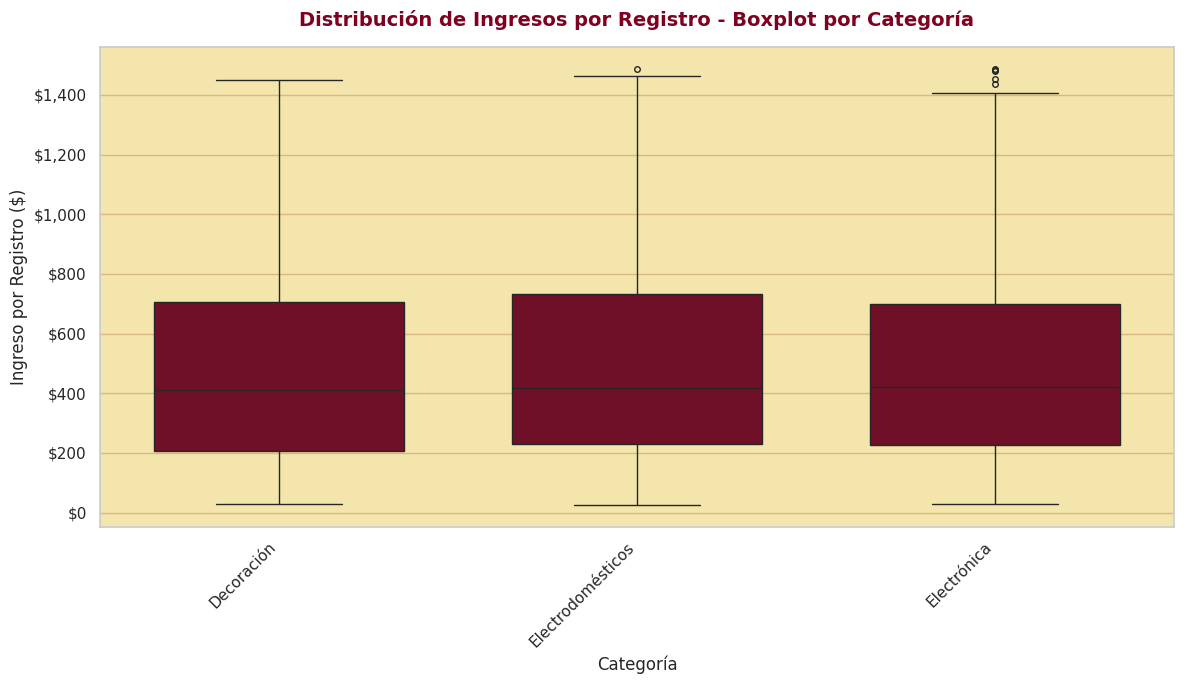

ANÁLISIS DE DISTRIBUCIÓN POR REGISTRO
Total de registros: 3,000
Categorías analizadas: 3
Rango de ingresos por registro: $26.30 - $1,488.12
Promedio por registro: $489.36

Estadísticas por categoría:
  Decoración: Media=$479.22, Mediana=$412.00
  Electrodomésticos: Media=$505.30, Mediana=$418.22
  Electrónica: Media=$483.54, Mediana=$419.58


In [659]:
# Boxplot por categoría - Ingreso por registro
plt.figure(figsize=(12, 7))

# Crear boxplot con personalización completa
ax = sns.boxplot(data=ventas_perf, x='categoria', y='ingreso',
                 color=PALETA_PRINCIPAL['bordo'],
                 width=0.7,
                 fliersize=4,
                 linewidth=1)

# Personalizar título y etiquetas
ax.set_title('Distribución de Ingresos por Registro - Boxplot por Categoría',
             fontsize=14, fontweight='bold', color=PALETA_PRINCIPAL['bordo'],
             pad=15)
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Ingreso por Registro ($)', fontsize=12)

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

# Configurar color de fondo
ax.set_facecolor(PALETA_PRINCIPAL['vainilla'])

# Formatear eje Y con separadores de miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Agregar grid sutil
ax.grid(axis='y', alpha=0.3, color=PALETA_PRINCIPAL['acento'])

# Ajustar márgenes
plt.tight_layout()
plt.show()

# Análisis complementario
print("ANÁLISIS DE DISTRIBUCIÓN POR REGISTRO")
print("=" * 50)
print(f"Total de registros: {len(ventas_perf):,}")
print(f"Categorías analizadas: {ventas_perf['categoria'].nunique()}")
print(f"Rango de ingresos por registro: ${ventas_perf['ingreso'].min():,.2f} - ${ventas_perf['ingreso'].max():,.2f}")
print(f"Promedio por registro: ${ventas_perf['ingreso'].mean():,.2f}")

# Calcular estadísticas por categoría
stats_categoria = ventas_perf.groupby('categoria')['ingreso'].agg(['mean', 'median', 'std']).round(2)
print(f"\nEstadísticas por categoría:")
for categoria in stats_categoria.index:
    mean_val = stats_categoria.loc[categoria, 'mean']
    median_val = stats_categoria.loc[categoria, 'median']
    print(f"  {categoria}: Media=${mean_val:,.2f}, Mediana=${median_val:,.2f}")

##4.3 Adicional de conclusiones con plotly.
#

In [660]:

# DASHBOARD INTERACTIVO - FILTROS SIMPLES


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preparar datos para filtros
resumen_prod_filtro = resumen_prod.copy()
categorias_disponibles = resumen_cat['categoria'].tolist()

# 1. DASHBOARD CON FILTROS BÁSICOS
fig_filtros = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Productos por Ingreso',
        'Precio vs Unidades',
        'Distribución por Categoría',
        'Top 5 Productos'
    ),
    specs=[
        [{"type": "bar"}, {"type": "scatter"}],
        [{"type": "pie"}, {"type": "bar"}]
    ]
)

# Gráfico 1: Barras - Top productos
top_10 = resumen_prod.nlargest(10, 'ingreso_total')
fig_filtros.add_trace(
    go.Bar(x=top_10['producto'], y=top_10['ingreso_total'],
           marker_color='#800020', name='Ingresos'),
    row=1, col=1
)

# Gráfico 2: Dispersión
fig_filtros.add_trace(
    go.Scatter(x=resumen_prod['precio_promedio'], y=resumen_prod['unidades'],
               mode='markers',
               marker=dict(size=8, color='#A0522D', opacity=0.7),
               name='Productos'),
    row=1, col=2
)

# Gráfico 3: Torta categorías
fig_filtros.add_trace(
    go.Pie(labels=resumen_cat['categoria'], values=resumen_cat['ingreso_total'],
           marker=dict(colors=['#800020', '#A0522D', '#F3E5AB']),
           name='Categorías'),
    row=2, col=1
)

# Gráfico 4: Top 5 productos
top_5 = resumen_prod.nlargest(5, 'ingreso_total')
fig_filtros.add_trace(
    go.Bar(x=top_5['producto'], y=top_5['ingreso_total'],
           marker_color='#A0522D', name='Top 5'),
    row=2, col=2
)

# Configuración final
fig_filtros.update_layout(
    height=700,
    title_text="Dashboard Analítico - Filtros Básicos",
    showlegend=False,
    plot_bgcolor='#F3E5AB',
    paper_bgcolor='#F3E5AB',
    font=dict(color='#800020', size=12)
)

fig_filtros.show()

# 2. SELECTOR DE RANGO DE INGRESOS
print("FILTRO POR RANGO DE INGRESOS")
print("=" * 35)

# Calcular rangos automáticamente
min_ingreso = resumen_prod['ingreso_total'].min()
max_ingreso = resumen_prod['ingreso_total'].max()
paso = (max_ingreso - min_ingreso) / 10

print(f"Rango disponible: ${min_ingreso:,.0f} - ${max_ingreso:,.0f}")

# Simular filtro (en entorno real sería un widget)
filtro_min = min_ingreso + paso * 3  # Percentil ~30%
filtro_max = min_ingreso + paso * 8  # Percentil ~80%

productos_filtrados = resumen_prod[
    (resumen_prod['ingreso_total'] >= filtro_min) &
    (resumen_prod['ingreso_total'] <= filtro_max)
]

print(f"Productos en rango seleccionado: {len(productos_filtrados)}")
print(f"Rango aplicado: ${filtro_min:,.0f} - ${filtro_max:,.0f}")

# Gráfico filtrado
fig_filtrado = px.bar(
    productos_filtrados.nlargest(8, 'ingreso_total'),
    x='producto',
    y='ingreso_total',
    title='Productos Filtrados por Rango de Ingresos',
    color='ingreso_total',
    color_continuous_scale=['#F3E5AB', '#800020']
)

fig_filtrado.update_layout(
    plot_bgcolor='#F3E5AB',
    paper_bgcolor='#F3E5AB',
    font=dict(color='#800020')
)

fig_filtrado.show()

# 3. RESUMEN INTERACTIVO
print("\nRESUMEN EJECUTIVO INTERACTIVO")
print("=" * 35)
print(f"Total productos analizados: {len(resumen_prod)}")
print(f"Productos en vista actual: {len(productos_filtrados)}")
print(f"Ingreso total vista actual: ${productos_filtrados['ingreso_total'].sum():,.0f}")
print(f"Producto destacado: {productos_filtrados.nlargest(1, 'ingreso_total').iloc[0]['producto']}")

# 4. BOTONES DE ACCIÓN RÁPIDA (simulados)
print("\nACCIONES RÁPIDAS:")
print("- Filtrar por categoría específica")
print("- Ajustar rango de precios")
print("- Ver productos con mayor crecimiento")
print("- Exportar datos filtrados")

FILTRO POR RANGO DE INGRESOS
Rango disponible: $11,129 - $82,276
Productos en rango seleccionado: 24
Rango aplicado: $32,473 - $68,047



RESUMEN EJECUTIVO INTERACTIVO
Total productos analizados: 30
Productos en vista actual: 24
Ingreso total vista actual: $1,175,356
Producto destacado: Cafetera

ACCIONES RÁPIDAS:
- Filtrar por categoría específica
- Ajustar rango de precios
- Ver productos con mayor crecimiento
- Exportar datos filtrados


**texto en negrita**
### 4.4 Presentación Final
Escribí un informe breve que resuma:
- **Productos líderes** y **categorías destacadas**.
- Diferencia **media vs. mediana** y su interpretación en estos datos.
- Presencia de **outliers** y su impacto.
- Recomendaciones sobre **qué productos potenciar** y **eficiencia de marketing**.


INFORME FINAL - CONCLUSIONES INTEGRALES

1. PRODUCTOS LÍDERES Y CATEGORÍAS DESTACADAS
---------------------------------------------
TOP 3 PRODUCTOS:
   1. Lámpara De Mesa: $82,276
   2. Auriculares: $74,176
   3. Microondas: $72,563

CATEGORÍAS DESTACADAS:
   1. Electrodomésticos: $505,300
   2. Electrónica: $482,578

2. ANÁLISIS DE DISTRIBUCIÓN
---------------------------------------------
Media:   $48,903
Mediana: $48,140
Diferencia: $763 (1.6%)
Coeficiente de variación: 27.1%
• Distribución balanceada

3. ANÁLISIS DE VALORES ATÍPICOS
---------------------------------------------
Productos excepcionales: 4
  • Lámpara De Mesa: $82,276
  • Auriculares: $74,176
  • Microondas: $72,563
  • Cafetera: $59,607
Impacto en ventas totales: 19.7%

4. RECOMENDACIONES ESTRATÉGICAS
---------------------------------------------
ACCIONES PRIORITARIAS:
• Potenciar productos líderes: replicar estrategias exitosas
• Invertir en categorías de alto rendimiento
• Capitalizar outliers: estudiar factores d

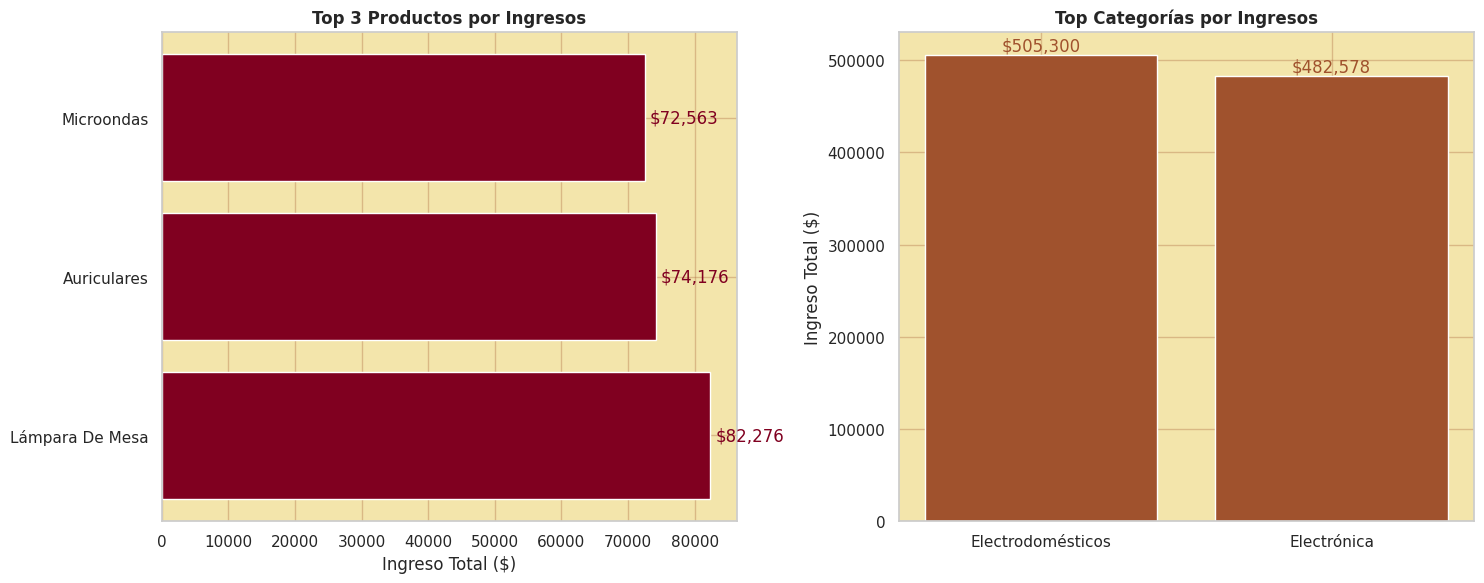


CONCLUSION: Enfoque en productos de alto desempeño
y replicacion de estrategias exitosas


In [661]:
# ====CONCLUSIONES INTEGRALES==== #

print("INFORME FINAL - CONCLUSIONES INTEGRALES")
print("=" * 45)

# 1. Productos líderes y categorías destacadas
print("\n1. PRODUCTOS LÍDERES Y CATEGORÍAS DESTACADAS")
print("-" * 45)

top_productos = resumen_prod.nlargest(3, 'ingreso_total')
top_categorias = resumen_cat.nlargest(2, 'ingreso_total')

print("TOP 3 PRODUCTOS:")
for i, (_, prod) in enumerate(top_productos.iterrows(), 1):
    print(f"   {i}. {prod['producto']}: ${prod['ingreso_total']:,.0f}")

print("\nCATEGORÍAS DESTACADAS:")
for i, (_, cat) in enumerate(top_categorias.iterrows(), 1):
    print(f"   {i}. {cat['categoria']}: ${cat['ingreso_total']:,.0f}")

# 2. Análisis Media vs Mediana
print("\n2. ANÁLISIS DE DISTRIBUCIÓN")
print("-" * 45)

media = resumen_prod['ingreso_total'].mean()
mediana = resumen_prod['ingreso_total'].median()
diferencia = abs(media - mediana)
coef_variacion = (resumen_prod['ingreso_total'].std() / media) * 100

print(f"Media:   ${media:,.0f}")
print(f"Mediana: ${mediana:,.0f}")
print(f"Diferencia: ${diferencia:,.0f} ({diferencia/media*100:.1f}%)")
print(f"Coeficiente de variación: {coef_variacion:.1f}%")

if diferencia / media > 0.15:
    print("• Distribución asimétrica - productos estrella elevan la media")
else:
    print("• Distribución balanceada")

# 3. Detección de outliers
print("\n3. ANÁLISIS DE VALORES ATÍPICOS")
print("-" * 45)

Q1 = resumen_prod['ingreso_total'].quantile(0.25)
Q3 = resumen_prod['ingreso_total'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = resumen_prod[resumen_prod['ingreso_total'] > limite_superior]
impacto_outliers = (outliers['ingreso_total'].sum() / resumen_prod['ingreso_total'].sum()) * 100

print(f"Productos excepcionales: {len(outliers)}")
if len(outliers) > 0:
    for _, outlier in outliers.iterrows():
        print(f"  • {outlier['producto']}: ${outlier['ingreso_total']:,.0f}")
    print(f"Impacto en ventas totales: {impacto_outliers:.1f}%")

# 4. Recomendaciones estratégicas
print("\n4. RECOMENDACIONES ESTRATÉGICAS")
print("-" * 45)

print("ACCIONES PRIORITARIAS:")
print("• Potenciar productos líderes: replicar estrategias exitosas")
print("• Invertir en categorías de alto rendimiento")
print("• Capitalizar outliers: estudiar factores de éxito")
print("• Optimizar marketing en productos con mejor ROI")

# Visualización resumen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico top productos
ax1.barh(top_productos['producto'], top_productos['ingreso_total'],
         color=PALETA_PRINCIPAL['bordo'])
ax1.set_title('Top 3 Productos por Ingresos', fontweight='bold')
ax1.set_xlabel('Ingreso Total ($)')
for i, v in enumerate(top_productos['ingreso_total']):
    ax1.text(v + v*0.01, i, f'${v:,.0f}', va='center',
             color=PALETA_PRINCIPAL['bordo'])

# Gráfico categorías
ax2.bar(top_categorias['categoria'], top_categorias['ingreso_total'],
        color=PALETA_PRINCIPAL['acento'])
ax2.set_title('Top Categorías por Ingresos', fontweight='bold')
ax2.set_ylabel('Ingreso Total ($)')
for i, v in enumerate(top_categorias['ingreso_total']):
    ax2.text(i, v + v*0.01, f'${v:,.0f}', ha='center',
             color=PALETA_PRINCIPAL['acento'])

# Estilo común
for ax in [ax1, ax2]:
    ax.grid(alpha=0.3, color=PALETA_PRINCIPAL['acento'])
    ax.set_facecolor(PALETA_PRINCIPAL['vainilla'])

plt.tight_layout()
plt.show()

print("\n" + "=" * 45)
print("CONCLUSION: Enfoque en productos de alto desempeño")
print("y replicacion de estrategias exitosas")

In [662]:
#Adicional de conclusiones con plotly.

# DASHBOARD - PALETA PRINCIPAL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("DASHBOARD EJECUTIVO - ANÁLISIS DE VENTAS")
print("=" * 40)

# Preparar datos clave
top_10 = resumen_prod.nlargest(10, 'ingreso_total')
top_cat = resumen_cat.nlargest(3, 'ingreso_total')

# Degradados de la paleta principal
degradado_bordo = ['#F9E6E6', '#E8C4C4', '#D7A3A3', '#C68181', '#B56060', '#A43E3E', '#931D1D', '#800020']
degradado_acento = ['#F3E5AB', '#E8D5A5', '#DDC59F', '#D2B599', '#C7A593', '#BC958D', '#B18587', '#A0522D']

# Dashboard simple 2x2
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Top 10 Productos',
        'Top 3 Categorías',
        'Análisis Outliers',
        'Precio vs Unidades'
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "scatter"}, {"type": "scatter"}]
    ]
)

# 1. Top 10 productos
fig.add_trace(
    go.Bar(
        y=top_10['producto'],
        x=top_10['ingreso_total'],
        orientation='h',
        marker_color=degradado_bordo[4],
        name='Productos'
    ),
    row=1, col=1
)

# 2. Top categorías
fig.add_trace(
    go.Bar(
        x=top_cat['categoria'],
        y=top_cat['ingreso_total'],
        marker_color=degradado_acento[6],
        name='Categorías'
    ),
    row=1, col=2
)

# 3. Análisis outliers
Q1 = resumen_prod['ingreso_total'].quantile(0.25)
Q3 = resumen_prod['ingreso_total'].quantile(0.75)
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR

outliers = resumen_prod[resumen_prod['ingreso_total'] > limite]
normales = resumen_prod[resumen_prod['ingreso_total'] <= limite]

fig.add_trace(
    go.Scatter(
        x=normales.index,
        y=normales['ingreso_total'],
        mode='markers',
        marker=dict(color=degradado_acento[3], size=8),
        name='Normales'
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=outliers.index,
        y=outliers['ingreso_total'],
        mode='markers',
        marker=dict(color=degradado_bordo[6], size=12),
        name='Outliers'
    ),
    row=2, col=1
)

# 4. Precio vs Unidades
fig.add_trace(
    go.Scatter(
        x=resumen_prod['precio_promedio'],
        y=resumen_prod['unidades'],
        mode='markers',
        marker=dict(
            size=8,
            color=resumen_prod['ingreso_total'],
            colorscale=[degradado_acento[2], degradado_acento[4], degradado_bordo[6]],
            showscale=True
        ),
        name='Precio vs Unidades'
    ),
    row=2, col=2
)

# Configuración minimalista
fig.update_layout(
    height=600,
    showlegend=True,
    plot_bgcolor=PALETA_PRINCIPAL['vainilla'],
    paper_bgcolor=PALETA_PRINCIPAL['vainilla'],
    font=dict(color=PALETA_PRINCIPAL['bordo'], size=11),
    margin=dict(t=80, b=60, l=60, r=60)
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor=degradado_acento[1])
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor=degradado_acento[1])

fig.show()

# Resumen ejecutivo
print(f"\nTOP PRODUCTO: {top_10.iloc[0]['producto']} (${top_10.iloc[0]['ingreso_total']:,.0f})")
print(f"OUTLIERS: {len(outliers)} productos")
print(f"CONCENTRACIÓN: {(top_10['ingreso_total'].sum()/resumen_prod['ingreso_total'].sum()*100):.1f}% en top 10")

DASHBOARD EJECUTIVO - ANÁLISIS DE VENTAS



TOP PRODUCTO: Lámpara De Mesa ($82,276)
OUTLIERS: 4 productos
CONCENTRACIÓN: 41.0% en top 10
